# Описание данных

## Таблица `Users`

| Поле              | Описание                                       |
|-------------------|------------------------------------------------|
| `user_id`         | Уникальный идентификатор пользователя.         |
| `registration_date` | Дата регистрации пользователя.                |
| `age`             | Возраст пользователя.                          |
| `gender`          | Пол.                                |
| `region`          | Регион.                                        |
| `acq_channel`     | Канал привлечения.                             |
| `buyer_segment`   | Сегмент покупателя.                            |
| `cohort_week`     | Неделя привлечения.|
| `cohort_month`    | Месяц привлечения. |

---

## Таблица `Events`

| Поле          | Описание                                                                 |
|---------------|--------------------------------------------------------------------------|
| `event_id`    | Уникальный идентификатор события.                                        |
| `user_id`     | Идентификатор пользователя.                                              |
| `event_date`  | Дата события.                                                            |
| `event_type`  | Тип события.   |
| `os`          | Операционная система.               |
| `device`      | Тип устройства.                                |
| `product_name`| Наименование товара, к которому относится событие (если применимо).      |
| `event_week`  | Неделя события.                                          |
| `event_month` | Месяц события .                                           |

---

## Таблица `Orders`

| Поле          | Описание                                                                 |
|---------------|--------------------------------------------------------------------------|
| `order_id`    | Уникальный идентификатор заказа.                                         |
| `user_id`     | Идентификатор пользователя, который сделал заказ |
| `order_date`  | Дата и время оформления заказа.                                          |
| `product_name`| Наименование товара.                                                     |
| `quantity`    | Количество единиц товара в заказе.                                       |
| `unit_price`  | Цена за одну единицу товара.                                             |
| `total_price` | Итоговая сумма заказа.                                                   |
| `category_name` | Наименование категории товара.                                         |
| `order_week`  | Неделя заказа.                                           |
| `order_month` | Месяц заказа.                                            |


## Таблица `Campaign_costs`

| Поле         | Описание                                                                 |
|--------------|--------------------------------------------------------------------------|
| `acq_channel`| Канал привлечения.  |
| `spend_month`| Месяц, в который был потрачен бюджет (отражает период, в котором были привлечены пользователи)                      |
| `budget`     | Маркетинговый бюджет (в денежном выражении), потраченный на данный канал в указанном месяце.                           |



## Описание событий

| Событие             | Описание                                                                                  |
|---------------------|-------------------------------------------------------------------------------------------|
| `page_view`         | Открытие любой страницы сайта или приложения пользователем.                                |
| `product_view`      | Просмотр страницы конкретного товара.                                                     |
| `product_click`     | Клик по товару (например, из списка товаров или на баннере).                              |
| `add_to_cart`       | Добавление товара в корзину.                                                              |
| `remove_from_cart`  | Удаление товара из корзины.                                                               |
| `search`            | Выполнение поиска по сайту или приложению.                                                |
| `filter_apply`      | Применение фильтра (например, по цене, бренду, категории).                                |
| `checkout_start`    | Начало оформления заказа (переход к оформлению корзины).                                  |
| `checkout_complete` | Завершение оформления заказа (не гарантирует покупку, покупка зависит от факта оплаты).                                          |
| `user_login`        | Вход пользователя в личный кабинет или аккаунт.                                           |
| `user_logout`       | Выход пользователя из аккаунта.                                                           |
| `wishlist_add`      | Добавление товара в список желаемого (wishlist).                                          |
| `category_view`     | Просмотр страницы категории товаров.                                                      |
| `banner_click`      | Клик по рекламному баннеру на сайте или в приложении.                                     |
| `promo_view`        | Просмотр промо-акции или специального предложения.                                        |


## Выручка маркетплейса = 5% от total_price

# Блок кода и расчета метрик

### Предобработка данных

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind

In [2]:
pa_marketplace_orders = pd.read_csv('',parse_dates=['order_date'])
pa_marketplace_campaign_costs = pd.read_csv('')
pa_marketplace_users = pd.read_csv('',parse_dates=['registration_date'])
pa_marketplace_events = pd.read_csv('',parse_dates=['event_date'])

In [3]:
pa_marketplace_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 31357 entries, 0 to 31356
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       31357 non-null  int64         
 1   user_id        31357 non-null  int64         
 2   order_date     31357 non-null  datetime64[us]
 3   product_name   31357 non-null  str           
 4   quantity       31357 non-null  int64         
 5   unit_price     31357 non-null  float64       
 6   total_price    31357 non-null  float64       
 7   category_name  31357 non-null  str           
 8   order_week     31357 non-null  str           
 9   order_month    31357 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(3), str(4)
memory usage: 2.4 MB


In [4]:
pa_marketplace_campaign_costs.info()

<class 'pandas.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   88 non-null     int64  
 1   acq_channel  88 non-null     str    
 2   spend_month  88 non-null     str    
 3   budget       88 non-null     float64
dtypes: float64(1), int64(1), str(2)
memory usage: 2.9 KB


In [5]:
pa_marketplace_users.info()

<class 'pandas.DataFrame'>
RangeIndex: 44151 entries, 0 to 44150
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            44151 non-null  int64         
 1   registration_date  44151 non-null  datetime64[us]
 2   age                44151 non-null  int64         
 3   gender             44151 non-null  str           
 4   region             44151 non-null  str           
 5   acq_channel        44151 non-null  str           
 6   buyer_segment      44151 non-null  str           
 7   cohort_week        44151 non-null  str           
 8   cohort_month       44151 non-null  str           
dtypes: datetime64[us](1), int64(2), str(6)
memory usage: 3.0 MB


In [6]:
pa_marketplace_events.info()

<class 'pandas.DataFrame'>
RangeIndex: 785859 entries, 0 to 785858
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   event_id      785859 non-null  int64         
 1   user_id       785859 non-null  int64         
 2   event_date    785859 non-null  datetime64[us]
 3   event_type    785859 non-null  str           
 4   os            785859 non-null  str           
 5   device        785859 non-null  str           
 6   product_name  385740 non-null  str           
 7   event_week    785859 non-null  str           
 8   event_month   785859 non-null  str           
dtypes: datetime64[us](1), int64(2), str(6)
memory usage: 54.0 MB


In [7]:
#Дату переводим в формат datetime
pa_marketplace_users['registration_date'] = pa_marketplace_users['registration_date'].dt.normalize()
pa_marketplace_events['event_date'] = pa_marketplace_events['event_date'].dt.normalize()
pa_marketplace_orders['order_date'] =pa_marketplace_orders['order_date'].dt.normalize()

In [8]:
print(f'Наличие пропусков в данных \n{pa_marketplace_orders.isnull().sum()}')
print(f'\nДубликаты в данных: {pa_marketplace_orders.duplicated().sum()}')

Наличие пропусков в данных 
order_id         0
user_id          0
order_date       0
product_name     0
quantity         0
unit_price       0
total_price      0
category_name    0
order_week       0
order_month      0
dtype: int64

Дубликаты в данных: 0


In [9]:
print(f'Наличие пропусков в данных \n{pa_marketplace_campaign_costs.isnull().sum()}')
print(f'\nДубликаты в данных: {pa_marketplace_campaign_costs.duplicated().sum()}')

Наличие пропусков в данных 
Unnamed: 0     0
acq_channel    0
spend_month    0
budget         0
dtype: int64

Дубликаты в данных: 0


In [10]:
print(f'Наличие пропусков в данных \n{pa_marketplace_users.isnull().sum()}')
print(f'\nДубликаты в данных: {pa_marketplace_users.duplicated().sum()}')

Наличие пропусков в данных 
user_id              0
registration_date    0
age                  0
gender               0
region               0
acq_channel          0
buyer_segment        0
cohort_week          0
cohort_month         0
dtype: int64

Дубликаты в данных: 0


In [11]:
print(f'Наличие пропусков в данных \n{pa_marketplace_events.isnull().sum()}')
print(f'\nДубликаты в данных: {pa_marketplace_events.duplicated().sum()}')

Наличие пропусков в данных 
event_id             0
user_id              0
event_date           0
event_type           0
os                   0
device               0
product_name    400119
event_week           0
event_month          0
dtype: int64

Дубликаты в данных: 0


### Обзор ключевых метрик

На данном этапе было выполнена верхнеуровневая оценка состояния продукта с помощью собранных витрин. Бизнес просит просто оценить текущее состояние — без глубокой сегментации и оценки сложных метрик.

Выручка бизнеса — 5% комиссии от стоимости любой продажи.

Цель — быстро получить целостную картину, не применяя сегментацию и не рассматривая глубокие срезы. Определите, соответствует ли продукт базовым ожиданиям, виден ли рост, есть ли тревожные сигналы.

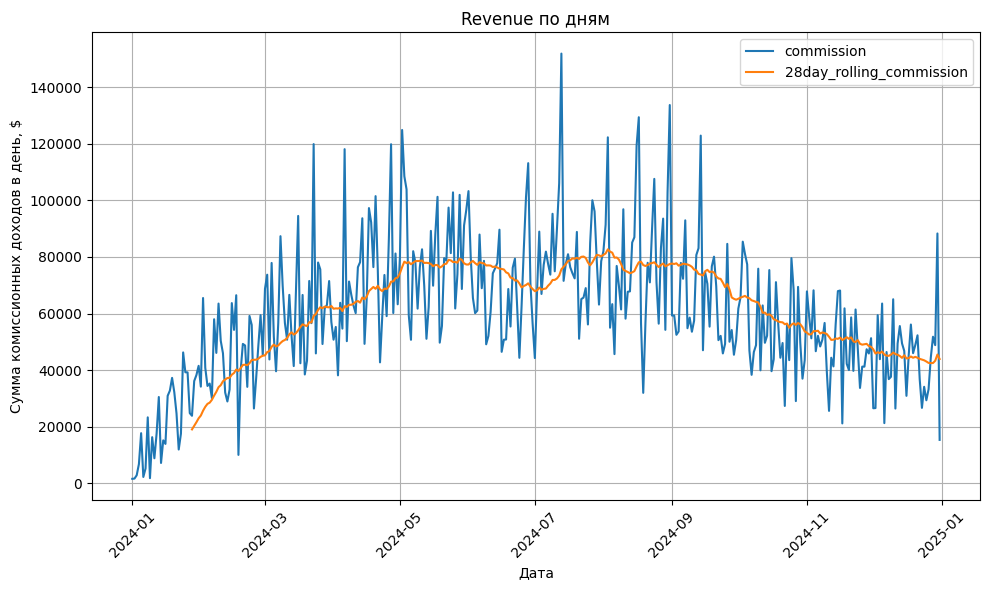

In [12]:
#Рассчёт Revenue (Доход)
pa_marketplace_orders['сommission'] = pa_marketplace_orders['total_price']*0.05
revenue = pa_marketplace_orders.groupby('order_date')['сommission'].sum().reset_index()

#Рассчёт скользящего среднего по 7 дням
revenue[ '28day_rolling_сommission' ] = revenue.сommission.rolling(28).mean()

#Визуализация Revenue
plt.figure(figsize=(10, 6))
plt.plot(revenue['order_date'], revenue['сommission'])
plt.plot(revenue['order_date'], revenue['28day_rolling_сommission'])
plt.title('Revenue по дням')
plt.xlabel('Дата')
plt.ylabel('Сумма комиссионных доходов в день, $')
plt.grid(True)
plt.legend(['сommission', '28day_rolling_сommission'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

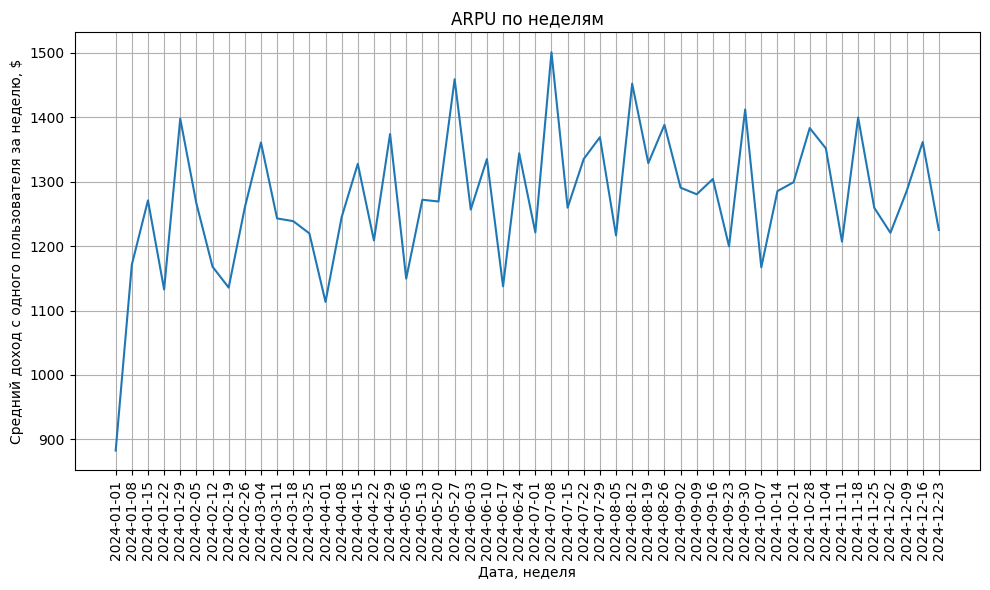

In [13]:
#Рассчёт ARPU (средний доход на пользователя)
week_сommission = pa_marketplace_orders.groupby('order_week')['сommission'].sum().reset_index()
week_users = pa_marketplace_orders.groupby('order_week')['user_id'].nunique().reset_index()
arpu = pd.merge(week_сommission, week_users, on='order_week', how = 'inner')
arpu['arpu'] = arpu['сommission']/arpu['user_id']

#Визуализация ARPU
plt.figure(figsize=(10, 6))
plt.plot(arpu['order_week'].iloc[:-1], arpu['arpu'].iloc[:-1])
plt.title('ARPU по неделям')
plt.xlabel('Дата, неделя')
plt.ylabel('Средний доход с одного пользователя за неделю, $')
plt.grid()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

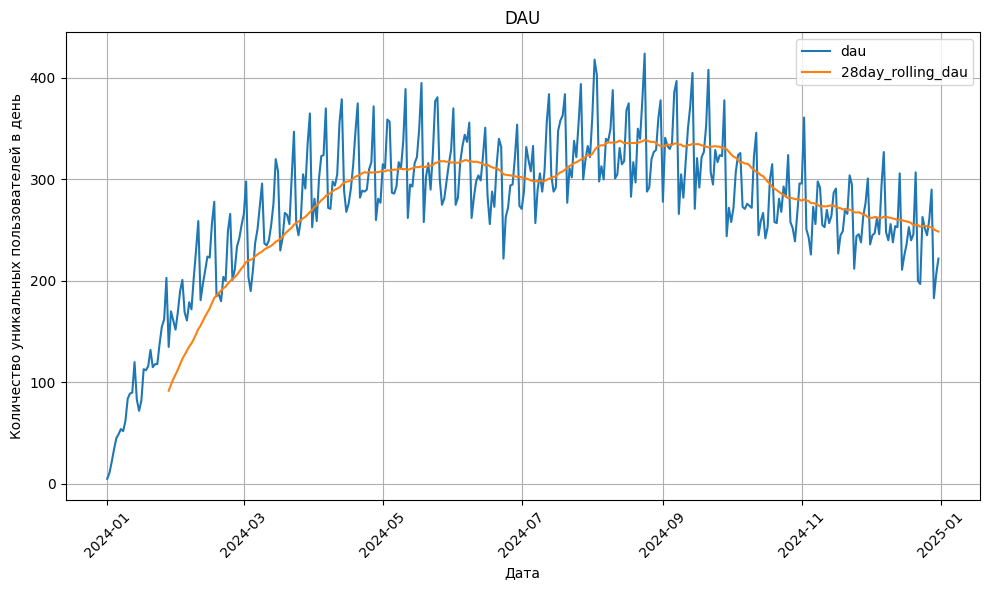

In [14]:
#Рассчёт DAU (Колличество активных пользователей в день)
dau = pa_marketplace_events[pa_marketplace_events['event_type']=='page_view'].groupby('event_date')['user_id'].nunique().reset_index()

#Рассчёт скользящего среднего по 7 дням
dau['28day_rolling_dau'] = dau.user_id.rolling(28).mean()

#Визуализация DAU
plt.figure(figsize=(10, 6))
plt.plot(dau['event_date'], dau['user_id'])
plt.plot(dau['event_date'], dau['28day_rolling_dau'])
plt.title('DAU')
plt.xlabel('Дата')
plt.ylabel('Количество уникальных пользователей в день')
plt.grid(True)
plt.legend(['dau', '28day_rolling_dau'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

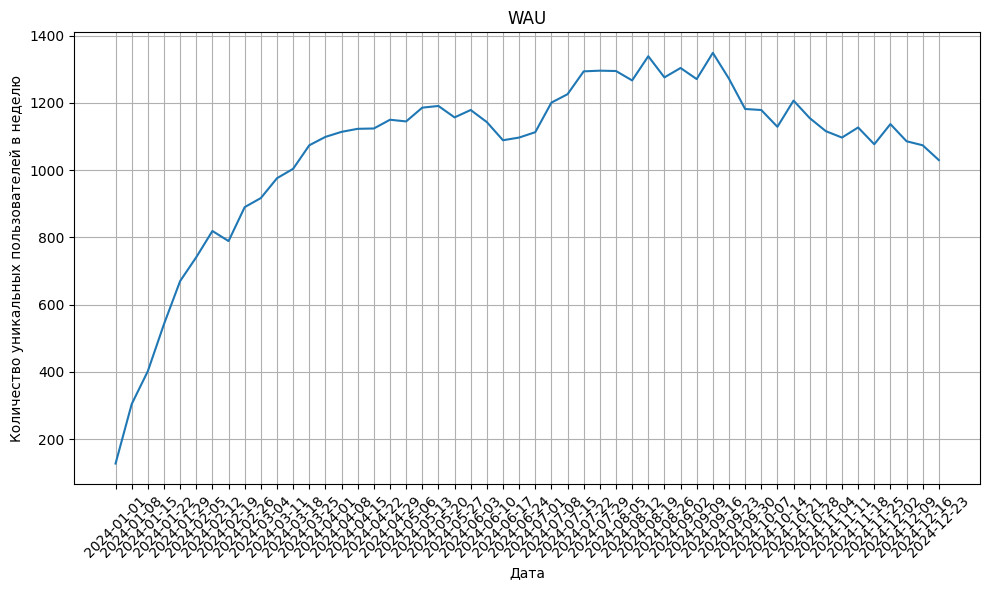

In [15]:
#Рассчёт WAU
wau = pa_marketplace_events[pa_marketplace_events['event_type']=='page_view'].groupby('event_week')['user_id'].nunique().reset_index()

#Визуализация WAU
plt.figure(figsize=(10, 6))
plt.plot(wau['event_week'][:-1], wau['user_id'][:-1])
plt.title('WAU')
plt.xlabel('Дата')
plt.ylabel('Количество уникальных пользователей в неделю')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

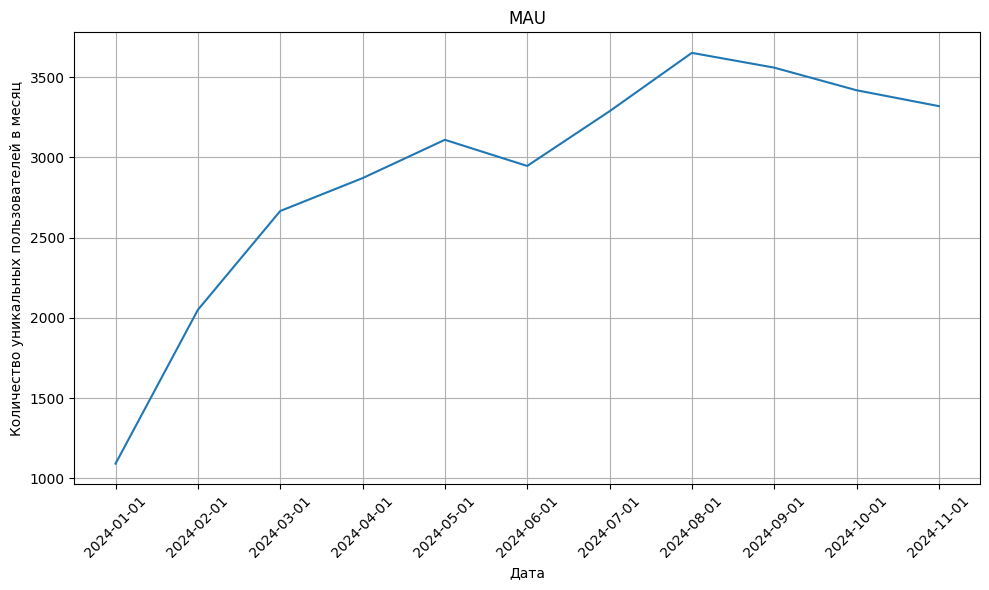

In [16]:
#Рассчёт MAU
mau = pa_marketplace_events[pa_marketplace_events['event_type']=='page_view'].groupby('event_month')['user_id'].nunique().reset_index()

#Визуализация MAU
plt.figure(figsize=(10, 6))
plt.plot(mau['event_month'][:-1], mau['user_id'][:-1])
plt.title('MAU')
plt.xlabel('Дата')
plt.ylabel('Количество уникальных пользователей в месяц')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

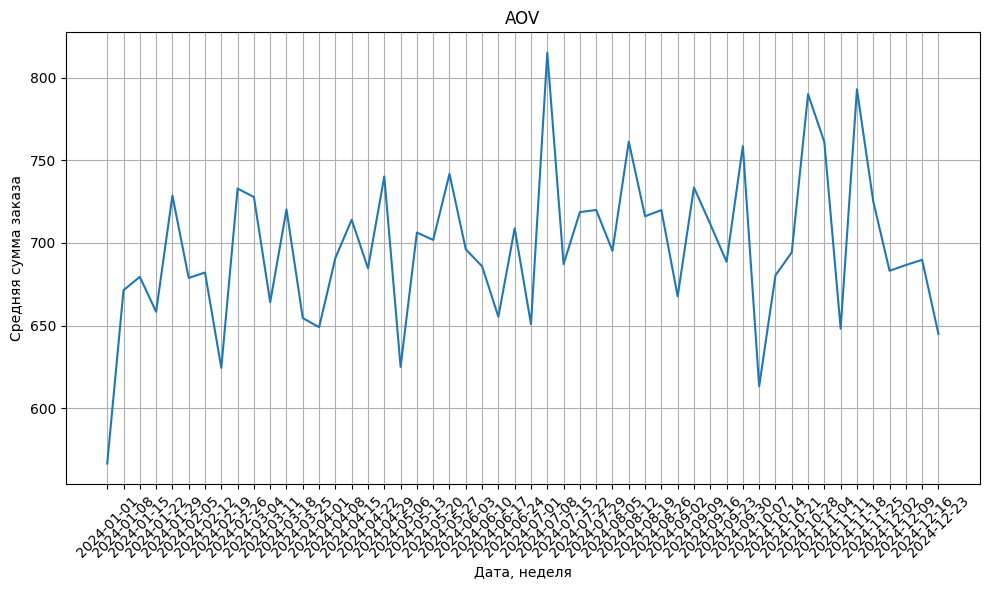

In [17]:
#Рассчёт AOV (Средний чек пользователя)
aov = pa_marketplace_orders.groupby('order_week').agg({'сommission': 'sum',
                                                      'order_id': 'nunique'}).reset_index()
aov['aov'] = aov['сommission']/aov['order_id']

#Визуализация AOV
plt.figure(figsize=(10, 6))
plt.plot(aov['order_week'].iloc[:-1], aov['aov'].iloc[:-1])
plt.title('AOV')
plt.xlabel('Дата, неделя')
plt.ylabel('Средняя сумма заказа')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
#Выделяем события входа и выхода в систему
retention = ['user_login', 'user_logout']
retention_df = pa_marketplace_events[pa_marketplace_events['event_type'].isin(retention)]

# Подсчет дней проведенных в личном кабинете
user_login = retention_df[retention_df['event_type']=='user_login'][['event_date','event_week','user_id']].rename(columns={'event_date':'user_login'})
user_logout = retention_df[retention_df['event_type']=='user_logout'][['event_date','user_id']].rename(columns={'event_date':'user_logout'})
retention_df = pd.merge(user_login, user_logout, on = 'user_id', how = 'left')
retention_df['retention_day'] = retention_df['user_logout'] - retention_df['user_login']

#Подсчёт пользователей, находившихся в личном кабинете менее 28 дней
retention_28_df = retention_df[(retention_df['retention_day'] > '13 days')&(retention_df['retention_day'] <= '28 days')].groupby('event_week')['user_id'].nunique().reset_index()
#Подсчёт общего числа пользователей
retention_df = retention_df[retention_df['retention_day'] > '0 days'].groupby('event_week')['user_id'].nunique().reset_index()

#Рассчёт Retention Rate (Доля клиентов, оставшихся с компанией за определённый период времени)
retention_df['retention']= retention_28_df['user_id']/retention_df['user_id']*100 

#Рассчёт скользящего среднего по 7 дням
retention_df['7retention_rolling_mau'] = retention_df.retention.rolling(7).mean()


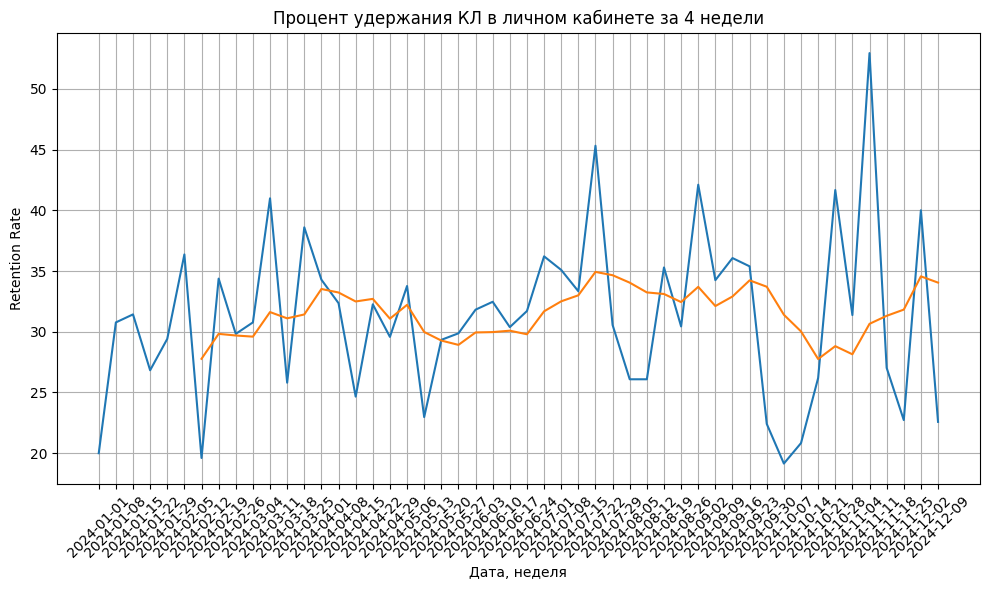

In [19]:
#Визуализация Retention Rate
retention_df = retention_df[retention_df['retention']<100]
plt.figure(figsize=(10, 6))
plt.plot(retention_df['event_week'], retention_df['retention'])
plt.plot(retention_df['event_week'], retention_df['7retention_rolling_mau'])
plt.title('Процент удержания КЛ в личном кабинете за 4 недели')
plt.xlabel('Дата, неделя')
plt.ylabel('Retention Rate')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

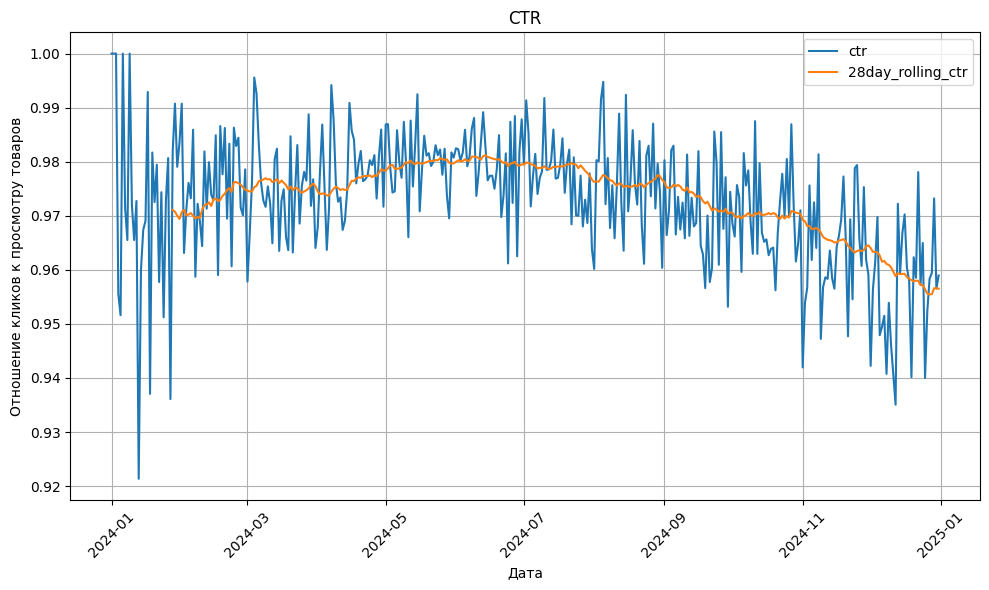

In [20]:
#Рассчёт CTR (Коэффициент кликабельности)
click = pa_marketplace_events[pa_marketplace_events['event_type']=='product_click'].groupby('event_date')['event_type'].count().reset_index().rename(columns={"event_type": "product_click"})
view = pa_marketplace_events[pa_marketplace_events['event_type']=='product_view'].groupby('event_date')['event_type'].count().reset_index().rename(columns={"event_type": "product_view"})
ctr = pd.merge(click, view, on = 'event_date', how='inner')
ctr['ctr'] = ctr['product_click']/ctr['product_view']

#Рассчёт скользящего среднего по 7 дням
ctr['28day_rolling_ctr'] = ctr.ctr.rolling(28).mean()

#Визуализация CTR
plt.figure(figsize=(10, 6))
plt.plot(ctr['event_date'], ctr['ctr'])
plt.plot(ctr['event_date'], ctr['28day_rolling_ctr'])
plt.title('CTR')
plt.xlabel('Дата')
plt.ylabel('Отношение кликов к просмотру товаров')
plt.legend(['ctr', '28day_rolling_ctr'])
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
#Подготавливаем данные для рассчёта воронки
conversion = ['page_view', 'product_view','product_click','add_to_cart','checkout_start','checkout_complete']
conversion_df = pa_marketplace_events[pa_marketplace_events['event_type'].isin(conversion)]
funnel_counts =  conversion_df.groupby('event_type')['user_id'].nunique().reindex(conversion)
# Собираем таблицу воронки
funnel_df = pd.DataFrame({
   'step':conversion,
   'users':funnel_counts.values
})
# Добавляем конверсии и округляем до 1 знака после запятой
funnel_df['conversion_from_first_%'] = (funnel_df['users'] / funnel_df['users'].iloc[0] * 100).round(1)
funnel_df['conversion_from_previous_%'] = (funnel_df['users'] / funnel_df['users'].shift(1) * 100).round(1)

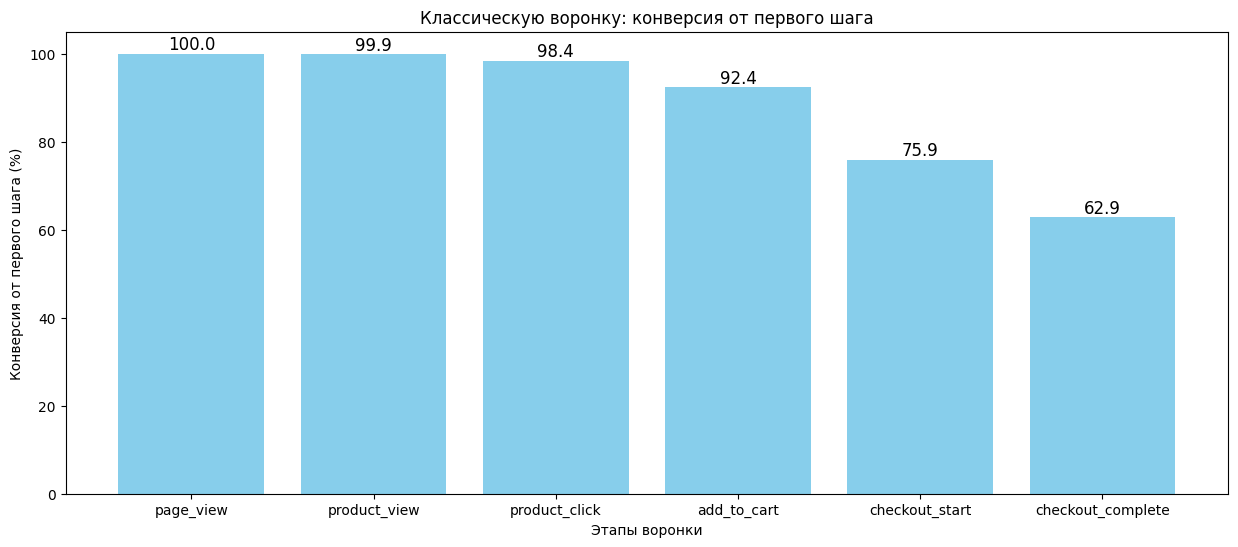

In [22]:
# Строим классическую воронку
plt.figure(figsize=(15, 6))
plt.bar(funnel_df['step'], funnel_df['conversion_from_first_%'], color='skyblue')
for i, v in enumerate(funnel_df['conversion_from_first_%']):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize=12)
plt.title('Классическую воронку: конверсия от первого шага')
plt.ylabel('Конверсия от первого шага (%)')
plt.xlabel('Этапы воронки')
plt.show()

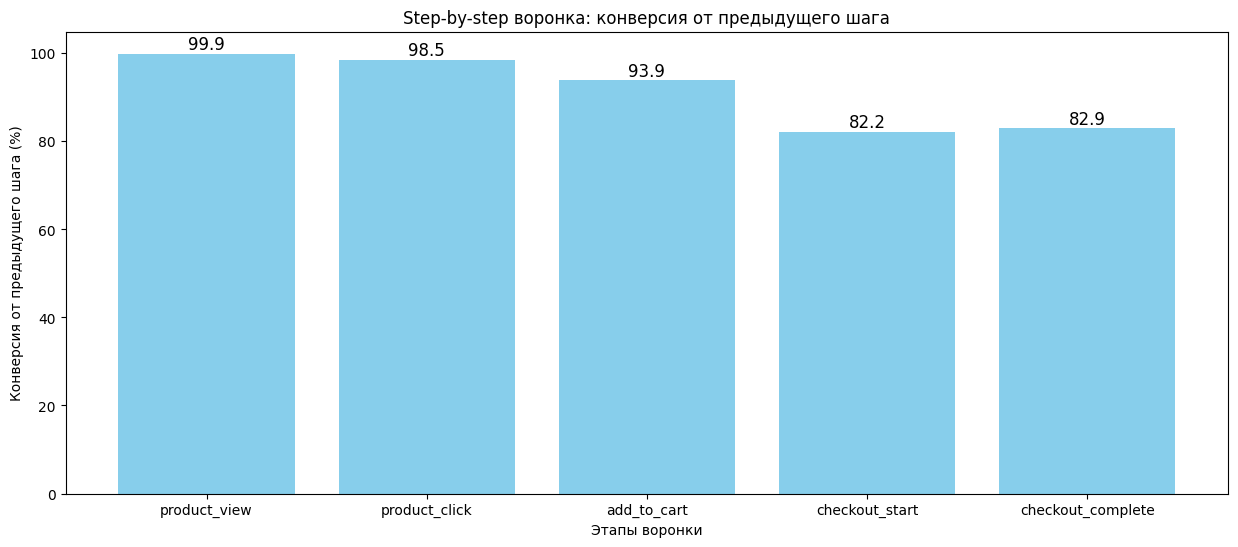

In [23]:
# Строим график step-by-step
plt.figure(figsize=(15, 6))
plt.bar(funnel_df['step'][1:], funnel_df['conversion_from_previous_%'][1:], color='skyblue')
for i, v in enumerate(funnel_df['conversion_from_previous_%'][1:]):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize=12)
plt.title('Step-by-step воронка: конверсия от предыдущего шага')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')
plt.show()

Средний доход от однго пользователя имеет высокую волатильность, однако к июлю заметен рост ARPU, после чего наблюдается спад. Сумма комиссионных доходов имеет аналогичную тенденцию. Средняя сумма на пике около 60 тыс, а концу года она приближается к отметке 40 тыс.

Колличество привлеченных пользователей с июля резко возрастает. С 2875 до 4375 новых пользователей за 1 мес. Показатель среднего чека с июля в боковом положении.

CTR (показатель кликабельности) с июля падает. Следовательно число просмотров становится больше, чем кликов. Вероятно новые пользователи приходят по ссылкам на конкретные товары. Но дальше не задерживаются в поисках нового товара или похожего.

Процент удержания КЛ в личном кабинете имеет высокую волатильность. Вероятно присутсвует сезонность. Период был взят от 13 до 28 дней.

Классическая воронка продаж показывает снижени пользователей, перешедших на этап завершения оформления заказа до 62,9%. Однако число пользователей снизилось до 82,9 % от предыдущего шага.


### Оценка метрик монетизации и юнит-экономики

Был выполнен анализ монетизации. Определено, сколько зарабатывает продукт и сколько тратит на привлечение.

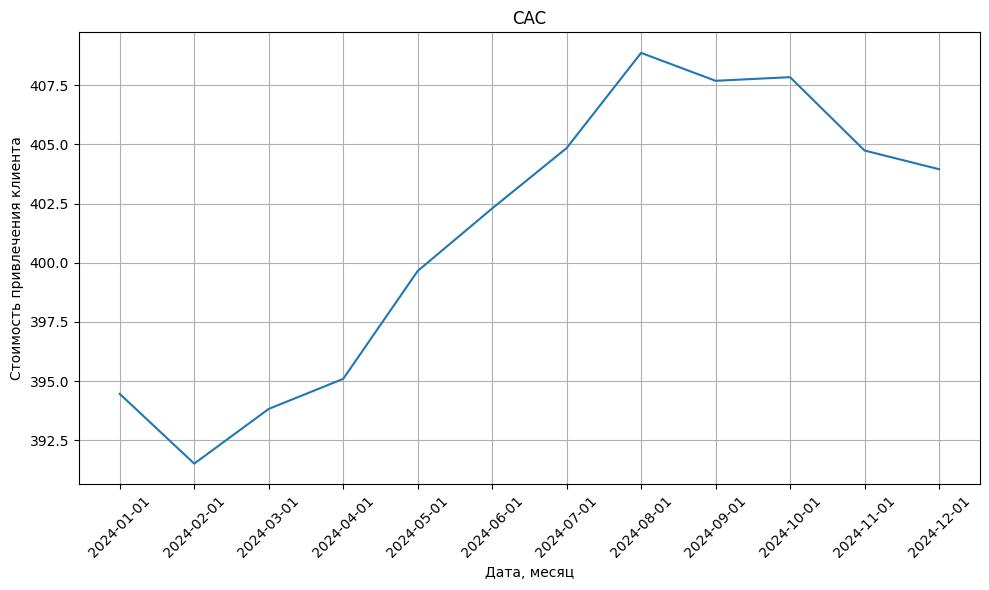

In [24]:
#Подготавливем датафрейм
campaign_costs = pa_marketplace_campaign_costs.groupby('spend_month')['budget'].sum().reset_index()
marketplace_users = pa_marketplace_users.groupby('cohort_month')['user_id'].nunique().reset_index()
#Рассчёт CAC ()Стоимость привлечения одного Клиента)
cac = pd.merge(campaign_costs, marketplace_users, left_on = 'spend_month', right_on='cohort_month', how='left')
cac['cac'] = cac['budget']/cac['user_id']

#Визуализация CAC
plt.figure(figsize=(10, 6))
plt.plot(cac['spend_month'], cac['cac'])
plt.title('CAC')
plt.xlabel('Дата, месяц')
plt.ylabel('Стоимость привлечения клиента')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
#Добавляем дату регистрации пользователей
orders = pd.merge(pa_marketplace_orders, pa_marketplace_users[['user_id', 'registration_date','cohort_month']], on='user_id', how='left')

#Подсчет дней от дня регистрации до офрмления заказа
orders['retention_day'] = orders['order_date'] - orders['registration_date']

#Фильтруем лайфтафм 28 дней 
orders = orders[orders['retention_day'] < '28 days']

In [26]:
#Выделяем завершения оформления заказа
events_checkout_complete = pa_marketplace_events[pa_marketplace_events['event_type']=='checkout_complete']
#Добавляем дату регистрации пользователей
events_checkout_complete = pd.merge(events_checkout_complete, pa_marketplace_users[['user_id', 'registration_date']], on='user_id', how='left')

#Подсчет дней от дня регистрации до завершения офрмления заказа
events_checkout_complete['retention_day'] = events_checkout_complete['event_date'] - events_checkout_complete['registration_date']

#Добавляем информацию о комиссионных доход от пользователя
events_checkout_complete = pd.merge(events_checkout_complete, pa_marketplace_orders[['user_id', 'order_date', 'сommission']], left_on = ['user_id', 'event_date'],right_on=['user_id', 'order_date'], how='left')

#Фильтруем лайфтафм 28 дней 
events_checkout_complete_28 = events_checkout_complete[events_checkout_complete['retention_day'] < '28 days']

In [27]:
#Группируем данные по числу пользователей и комиссионных доходах по месяцу привлечения превлечения
ltv_users = events_checkout_complete_28.groupby('event_month')['user_id'].nunique().reset_index()
ltv_сommission = events_checkout_complete_28.groupby('event_month')['сommission'].sum().reset_index()
ltv = pd.merge(ltv_users, ltv_сommission, on='event_month', how='left')

#Рассчёт LTV (Пожизненная ценность Клиента)
ltv['ltv'] = ltv['сommission']/ltv['user_id']

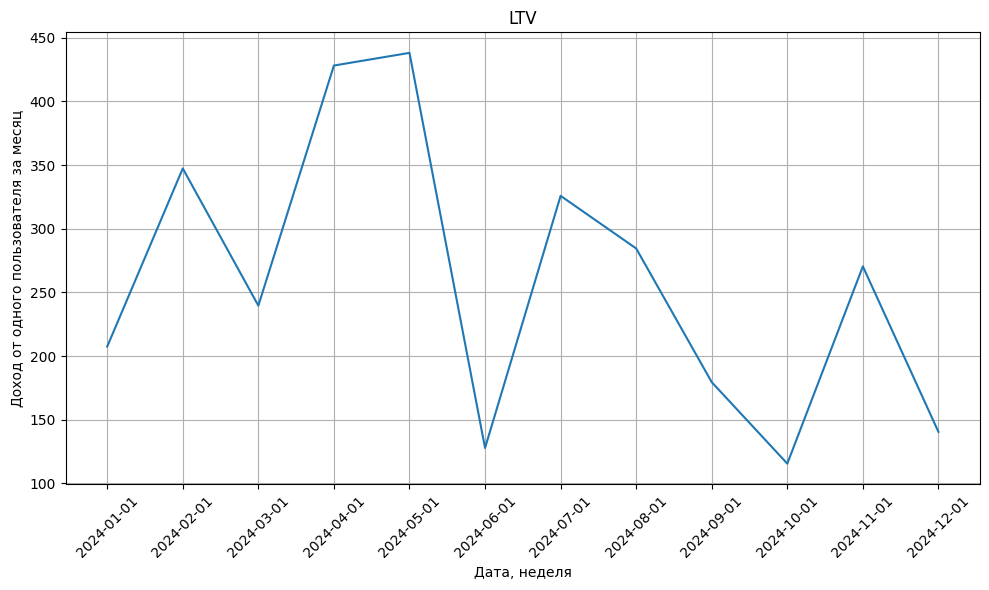

In [28]:
#Визуализация LTV
plt.figure(figsize=(10, 6))
plt.plot(ltv['event_month'], ltv['ltv'])
plt.title('LTV')
plt.xlabel('Дата, неделя')
plt.ylabel('Доход от одного пользователя за месяц')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

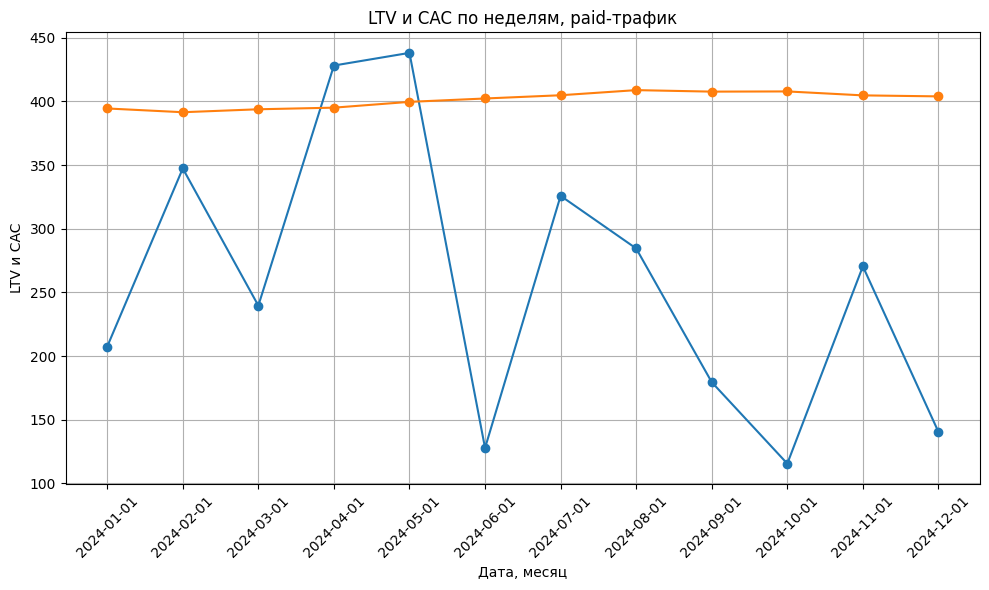

In [29]:
cac_value = cac['cac'].mean()
#LTV и CAC по неделям, paid-трафик
plt.figure(figsize=(10, 6))
plt.plot(ltv['event_month'], ltv['ltv'],marker='o')
plt.plot(cac['spend_month'], cac['cac'],marker='o')
plt.title('LTV и CAC по неделям, paid-трафик')
plt.xlabel('Дата, месяц')
plt.ylabel('LTV и CAC')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

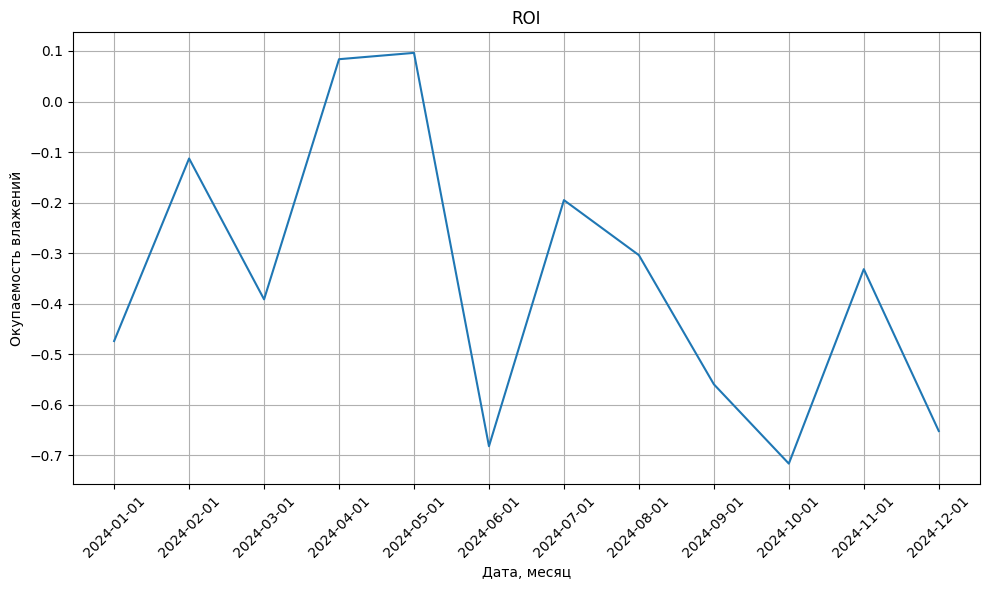

In [30]:
#Рассчёт ROI (Показатель окупаемости инвестиций)
roi = pd.merge(cac, ltv, left_on = 'spend_month', right_on='event_month', how='left')
roi['roi'] = (roi['ltv'] - roi['cac'])/roi['cac']

#Визуализация ROI
plt.figure(figsize=(10, 6))
plt.plot(roi['spend_month'], roi['roi'])
plt.title('ROI')
plt.xlabel('Дата, месяц')
plt.ylabel('Окупаемость влажений')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Стоимость привлечения пользователей увеличивается до июля и на пик составляет примерно 408 единиц. Далее показатель незначительно снижается. Доход от одного пользователяя за период 28 дней в апреле достигает пика, свыше 225 единиц, но уже к декабрю опускается ниже 75 единиц. Проект окупается только в марте, а далее имеет нисходящий тренд. 

## Выводы по этапам 6.2 и 6.3

Число новых пользователей на маркетплейсе увеличивается. В июле был резкий скачёк. Вероятно анамальный рост был связан с одним или парой каналами привлечения. Люди часто просматривают товары но кликают поним. Т.е. перейдя по ссылке на товар, пользователи не реже совершают просмотры похожих или сопутсвующих товаров. Следует добавить данные функции, изменить расположение поля рекомендаций товаров или изменить алгоритм.

Замечено снижении конверси на этапе начала оформления заказ и его завершения, она опускается до 76 и 63 процентов соответсвенно.

Мы выяснили, что маркетинговая компания не окупается ROI отрицательная. Однако это допустимо при достаточной финансовой устойчивости, если основной целью являлось привлевчение новых пользователей и их удержание. Данное явление характерно для молодых IT продуктов. И действительно, начиная с июля пользователи дольше задерживаются в своих личных кабинетах и невыходят. Следовательно можно начинать стимулировать их на покупки дешёвыми или бесплатными каналами, например пуш-уведомления, email-рассылка. Так как доход на однго пользователя (ltv) за период 28 дней начинает снижаться с апреля.

## Поиск инсайтов, точек роста и сегментация

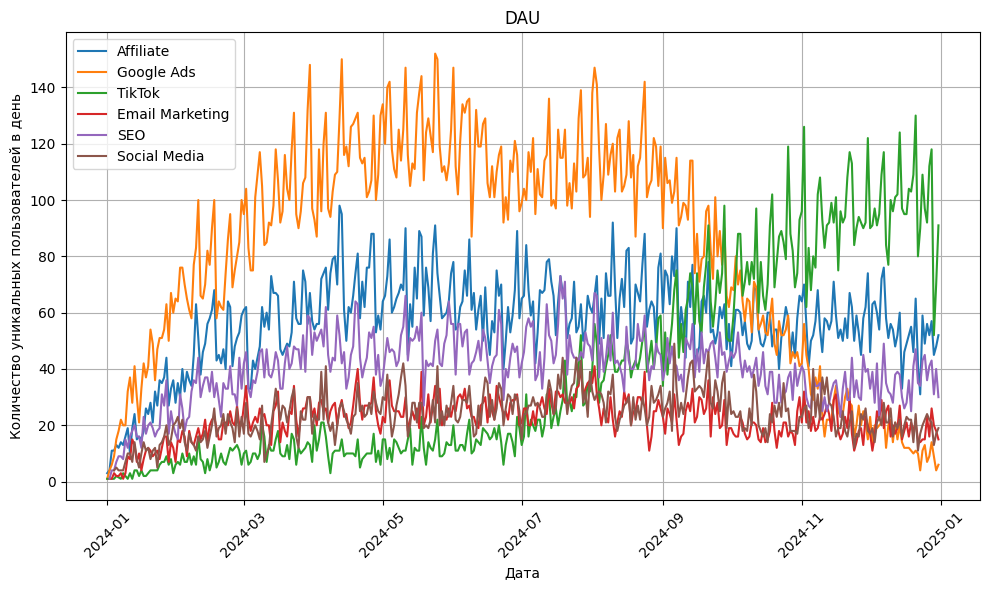

In [31]:
#Рассчёт DAU
dau_channel = pd.merge(pa_marketplace_events, pa_marketplace_users[['user_id', 'acq_channel']], on='user_id', how='left')
dau_channel = dau_channel[dau_channel['event_type']=='page_view'].groupby(['event_date','acq_channel'])['user_id'].nunique().reset_index()

#Визуализация DAU
plt.figure(figsize=(10, 6))
sns.lineplot(
        data=dau_channel,
        x='event_date',
        y='user_id',
        hue='acq_channel'
    )
plt.title('DAU')
plt.xlabel('Дата')
plt.ylabel('Количество уникальных пользователей в день')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

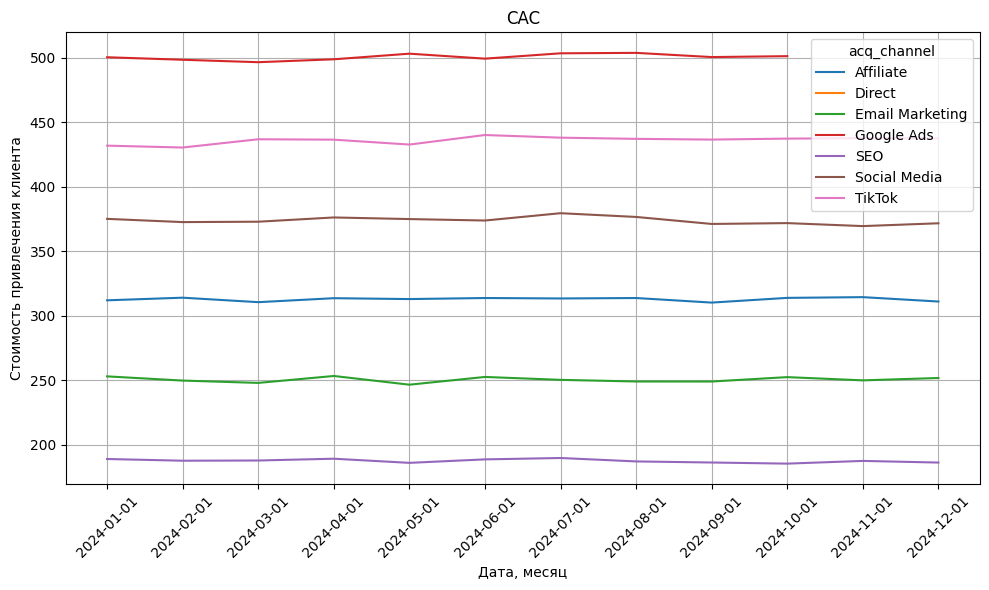

In [32]:
#Подготавливем датафрейм CAC по каналам привлечения
campaign_costs_channel = pa_marketplace_campaign_costs.groupby(['acq_channel','spend_month'])['budget'].sum().reset_index()
marketplace_users_channel = pa_marketplace_users.groupby(['acq_channel','cohort_month'])['user_id'].nunique().reset_index()
#Рассчёт CAC
cac_channel = pd.merge(campaign_costs_channel, marketplace_users_channel, left_on = ['acq_channel','spend_month'], right_on=['acq_channel','cohort_month'], how='left')
cac_channel['cac'] = cac_channel['budget']/cac_channel['user_id']

#Визуализация CAC по каналам привлечения
plt.figure(figsize=(10, 6))
sns.lineplot(
        data=cac_channel,
        x='spend_month',
        y='cac',
        hue='acq_channel'
    )
plt.title('CAC')
plt.xlabel('Дата, месяц')
plt.ylabel('Стоимость привлечения клиента')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
#Рассчёт MAU
mau_channel = pd.merge(pa_marketplace_events, pa_marketplace_users[['user_id', 'acq_channel']], on='user_id', how='left')
mau_channel = mau_channel[mau_channel['event_type']=='page_view'].groupby(['event_month','acq_channel'])['user_id'].nunique().reset_index().rename(columns={'user_id':'mau'})

dau_channel = pd.merge(pa_marketplace_events, pa_marketplace_users[['user_id', 'acq_channel']], on='user_id', how='left')
dau_channel = dau_channel[dau_channel['event_type']=='page_view'].groupby(['event_date','acq_channel','event_month'])['user_id'].nunique().reset_index().rename(columns={'user_id':'dau'})
#Рассчёт Stickiness 
stickiness_grouped = pd.merge(dau_channel, mau_channel, on=['acq_channel', 'event_month'], how='left')
stickiness_grouped['stickiness'] = stickiness_grouped['dau']/stickiness_grouped['mau']

/tmp/ipykernel_7605/2367212943.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


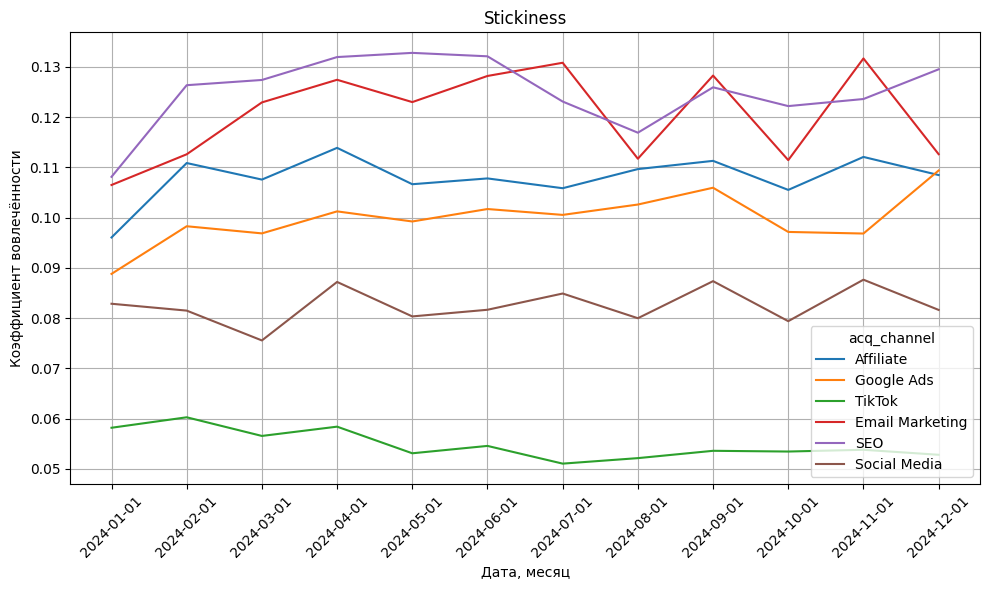

In [34]:
#Визуализация Stickiness по каналам привлечения
plt.figure(figsize=(10, 6))
sns.lineplot(
        data=stickiness_grouped,
        x='event_month',
        y='stickiness',
        hue='acq_channel',
        ci=None
    )
plt.title('Stickiness')
plt.xlabel('Дата, месяц')
plt.ylabel('Коэффициент вовлечённости')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
#Выделяем события входа и выхода в систему
retention = ['user_login', 'user_logout']
retention_df = pa_marketplace_events[pa_marketplace_events['event_type'].isin(retention)]

# Подсчет дней проведенных в личном кабинете
user_login = retention_df[retention_df['event_type']=='user_login'][['event_date','event_week','user_id','device']].rename(columns={'event_date':'user_login'})
user_logout = retention_df[retention_df['event_type']=='user_logout'][['event_date','user_id','device']].rename(columns={'event_date':'user_logout'})
retention_df = pd.merge(user_login, user_logout, on = ['user_id','device'], how = 'left')
retention_df_channel = pd.merge(retention_df, pa_marketplace_users[['user_id', 'acq_channel']], on = 'user_id', how = 'left')
retention_df_channel['retention_day'] = retention_df['user_logout'] - retention_df['user_login']

#Подсчёт пользователей, находившихся в личном кабинете за период с 14-го по 28-й день
retention_13_28_df = retention_df_channel[(retention_df_channel['retention_day'] > '13 days')&(retention_df_channel['retention_day'] <= '28 days')]
retention_13_28_df_channel = retention_13_28_df.groupby(['event_week', 'acq_channel'])['user_id'].nunique().reset_index()
#Подсчёт общего числа пользователей
retention_df_channel = retention_df_channel[retention_df_channel['retention_day'] > '0 days']
retention_df_channel= retention_df_channel.groupby(['event_week', 'acq_channel'])['user_id'].nunique().reset_index()

#Рассчёт retention rate (Скользящее удержание на 14-й день с момента привлечения)
retention_df_channel['retention']= retention_13_28_df_channel['user_id']/retention_df_channel['user_id']*100

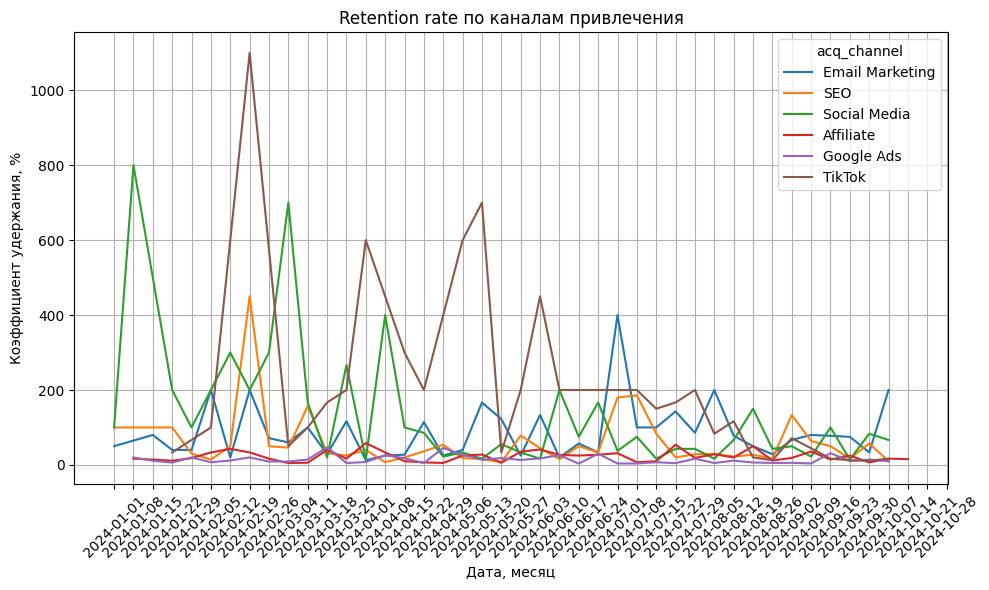

In [36]:
#Визуализация Stickiness по каналам привлечения
plt.figure(figsize=(10, 6))
sns.lineplot(
        data=retention_df_channel,
        x='event_week',
        y='retention',
        hue='acq_channel'
    )
plt.title('Retention rate по каналам привлечения')
plt.xlabel('Дата, месяц')
plt.ylabel('Коэффициент удержания, %')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [37]:
#Выделяем события входа и выхода в систему
retention = ['user_login', 'user_logout']
retention_df = pa_marketplace_events[pa_marketplace_events['event_type'].isin(retention)]

# Подсчет дней проведенных в личном кабинете
user_login = retention_df[retention_df['event_type']=='user_login'][['event_date','event_week','user_id','device']].rename(columns={'event_date':'user_login'})
user_logout = retention_df[retention_df['event_type']=='user_logout'][['event_date','user_id','device']].rename(columns={'event_date':'user_logout'})
retention_df = pd.merge(user_login, user_logout, on = ['user_id','device'], how = 'left')
retention_df_device = pd.merge(retention_df, pa_marketplace_users[['user_id', 'acq_channel']], on = 'user_id', how = 'left')
retention_df_device['retention_day'] = retention_df['user_logout'] - retention_df['user_login']

#Подсчёт пользователей, находившихся в личном кабинете за период с 14-го по 28-й день
retention_13_28_df = retention_df_device[(retention_df_device['retention_day'] > '13 days')&(retention_df_device['retention_day'] <= '28 days')]
retention_13_28_df_device = retention_13_28_df.groupby(['event_week', 'device'])['user_id'].nunique().reset_index()
#Подсчёт общего числа пользователей
retention_df_device = retention_df_device[retention_df_device['retention_day'] > '0 days']
retention_df_device= retention_df_device.groupby(['event_week', 'device'])['user_id'].nunique().reset_index()

#Рассчёт retention rate (Скользящее удержание на 14-й день с момента привлечения)
retention_df_device['retention']= retention_13_28_df_device['user_id']/retention_df_device['user_id']*100 

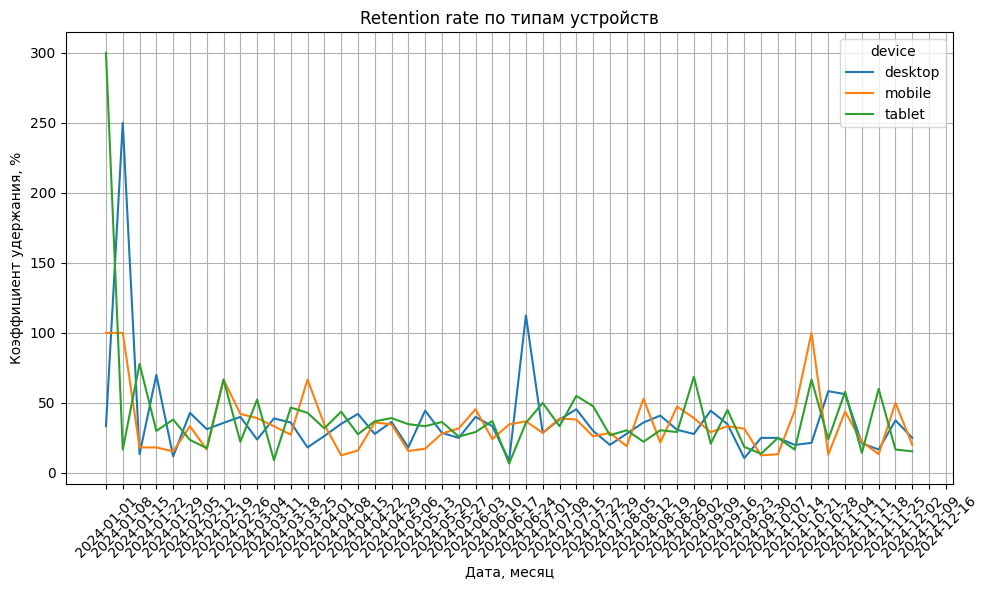

In [38]:
#Визуализация retention rate по каналам привлечения
plt.figure(figsize=(10, 6))
sns.lineplot(
        data=retention_df_device,
        x='event_week',
        y='retention',
        hue='device'
    )
plt.title('Retention rate по типам устройств')
plt.xlabel('Дата, месяц')
plt.ylabel('Коэффициент удержания, %')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
#Выделяем завершение оформления заказа
events_checkout_complete = pa_marketplace_events[pa_marketplace_events['event_type']=='checkout_complete']
#Добавляем дату регистрации пользователей
events_checkout_complete_channel = pd.merge(events_checkout_complete, pa_marketplace_users[['user_id', 'registration_date','acq_channel']], on='user_id', how='left')

#Подсчет дней от дня регистрации до завершения офрмления заказа
events_checkout_complete_channel['retention_day'] = events_checkout_complete_channel['event_date'] - events_checkout_complete_channel['registration_date']

#Добавляем информацию о комиссионных доход от пользователя
events_checkout_complete_channel = pd.merge(events_checkout_complete_channel, pa_marketplace_orders[['user_id', 'order_date', 'сommission']], left_on = ['user_id', 'event_date'],right_on=['user_id', 'order_date'], how='left')

#Фильтруем лайфтафм 28 дней 
events_checkout_complete_channel_28 = events_checkout_complete_channel[events_checkout_complete_channel['retention_day'] < '28 days']

In [40]:
#Группируем данные по числу пользователей и комиссионных доходах по месяцу привлечения превлечения
ltv_users_channel = events_checkout_complete_channel_28.groupby(['event_month','acq_channel'])['user_id'].nunique().reset_index()
ltv_сommission_channel = events_checkout_complete_channel_28.groupby(['event_month','acq_channel'])['сommission'].sum().reset_index()
ltv_channel = pd.merge(ltv_users_channel, ltv_сommission_channel, on=['event_month','acq_channel'], how='left')

#Рассчёт ltv
ltv_channel['ltv'] = ltv_channel['сommission']/ltv_channel['user_id']

/tmp/ipykernel_7605/2981738956.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


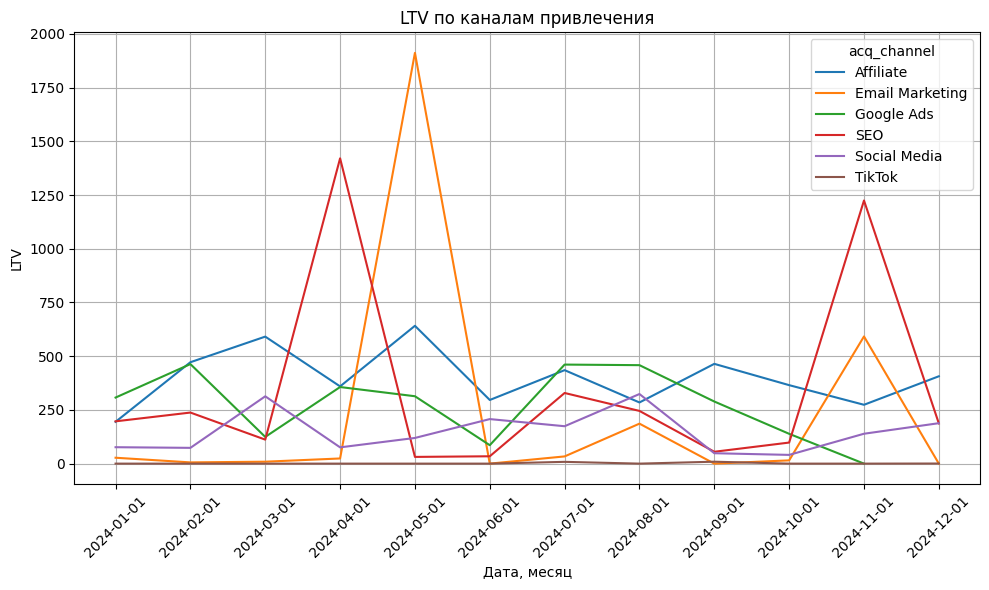

In [41]:
#Визуализация LTV по каналам привлечения
plt.figure(figsize=(10, 6))
sns.lineplot(
        data=ltv_channel,
        x='event_month',
        y='ltv',
        hue='acq_channel',
        ci=None
    )
plt.title('LTV по каналам привлечения')
plt.xlabel('Дата, месяц')
plt.ylabel('LTV')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [42]:
#Группируем данные по числу пользователей и комиссионных доходах по месяцу привлечения превлечения
ltv_users_device = events_checkout_complete_channel_28.groupby(['event_month','device'])['user_id'].nunique().reset_index()
ltv_сommission_device = events_checkout_complete_channel_28.groupby(['event_month','device'])['сommission'].sum().reset_index()
ltv_device = pd.merge(ltv_users_device, ltv_сommission_device, on=['event_month','device'], how='left')

#Рассчёт ltv
ltv_device['ltv'] = ltv_device['сommission']/ltv_device['user_id']

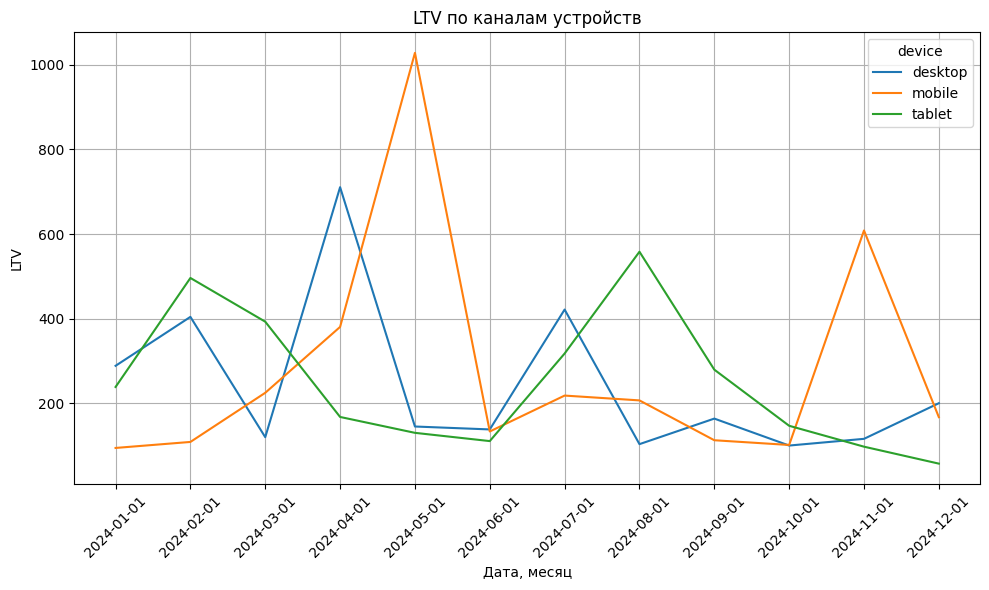

In [43]:
#Визуализация LTV по типам устройств
plt.figure(figsize=(10, 6))
sns.lineplot(
        data=ltv_device,
        x='event_month',
        y='ltv',
        hue='device'
    )
plt.title('LTV по каналам устройств')
plt.xlabel('Дата, месяц')
plt.ylabel('LTV')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:
#Подготавливаем данные для рассчёта конверсии от шага просмотра к оформлению заказа
conversion = ['page_view', 'checkout_complete']
conversion_df = pa_marketplace_events[pa_marketplace_events['event_type'].isin(conversion)]
conversion_df = pd.merge(conversion_df, pa_marketplace_orders, left_on=['user_id', 'event_date'], right_on=['user_id', 'order_date'], how='left')
conversion_page_view = conversion_df[conversion_df['event_type']=='page_view'].groupby('category_name')['user_id'].nunique()
conversion_checkout_complete = conversion_df[conversion_df['event_type']=='checkout_complete'].groupby('category_name')['user_id'].nunique()

# Рассчёт конверсии по типу товаров
funnel_df = (conversion_checkout_complete / conversion_page_view * 100).round(1).reset_index().rename(columns={'user_id':'conversion'})

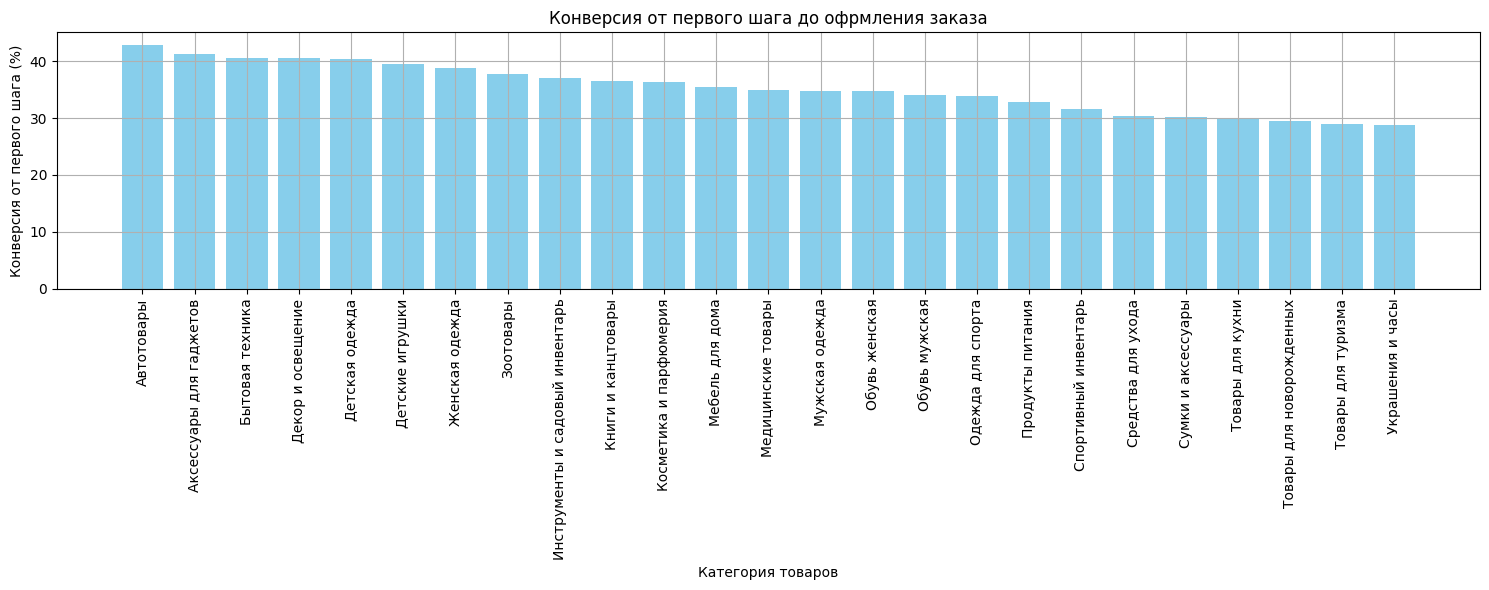

In [45]:
# Строим конверсию от просмотра страници до офрмления заказа
plt.figure(figsize=(15, 6))
plt.bar(funnel_df['category_name'], funnel_df['conversion'].sort_values(ascending=False), color='skyblue')
plt.title('Конверсия от первого шага до офрмления заказа')
plt.ylabel('Конверсия от первого шага (%)')
plt.xlabel('Категория товаров')
plt.grid(True)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

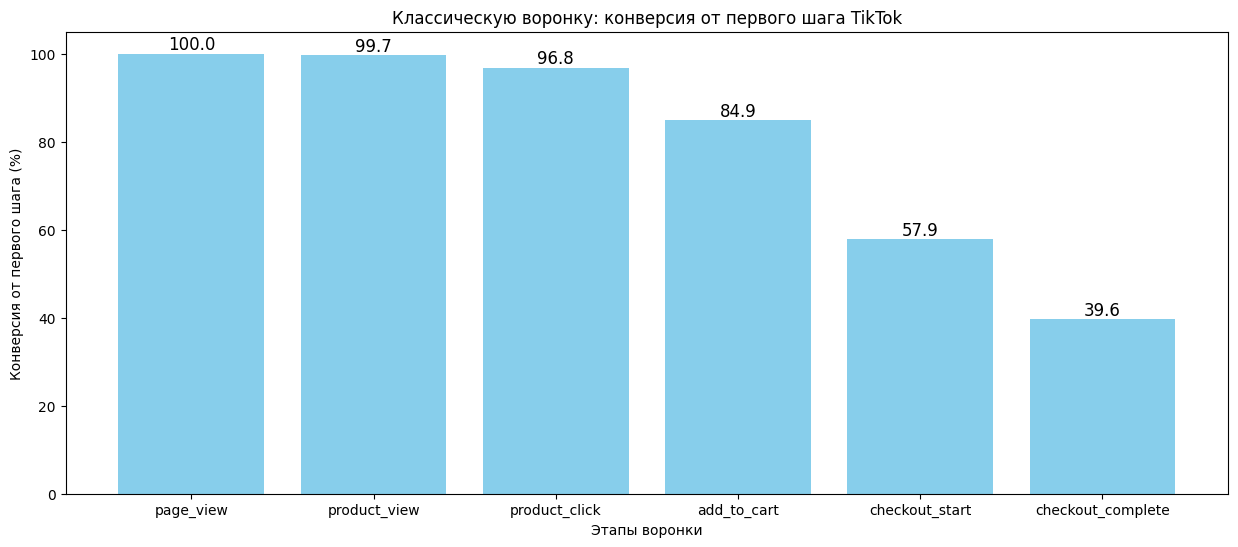

In [46]:
#Подготавливаем данные для рассчёта воронки
conversion = ['page_view', 'product_view','product_click','add_to_cart','checkout_start','checkout_complete']
conversion_df = pd.merge(pa_marketplace_events, pa_marketplace_users[['user_id', 'acq_channel']], on='user_id', how='left')
conversion_df = conversion_df[conversion_df['acq_channel']=='TikTok'] 
funnel_counts =  conversion_df.groupby('event_type')['user_id'].nunique().reindex(conversion)

# Собираем таблицу воронки
funnel_df = pd.DataFrame({
   'step':conversion,
   'users':funnel_counts.values
})
# Добавляем конверсии и округляем до 1 знака после запятой
funnel_df['conversion_from_first_%'] = (funnel_df['users'] / funnel_df['users'].iloc[0] * 100).round(1)
funnel_df['conversion_from_previous_%'] = (funnel_df['users'] / funnel_df['users'].shift(1) * 100).round(1)

# Строим классическую воронку
plt.figure(figsize=(15, 6))
plt.bar(funnel_df['step'], funnel_df['conversion_from_first_%'], color='skyblue')
for i, v in enumerate(funnel_df['conversion_from_first_%']):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize=12)
plt.title('Классическую воронку: конверсия от первого шага TikTok')
plt.ylabel('Конверсия от первого шага (%)')
plt.xlabel('Этапы воронки')
plt.show()

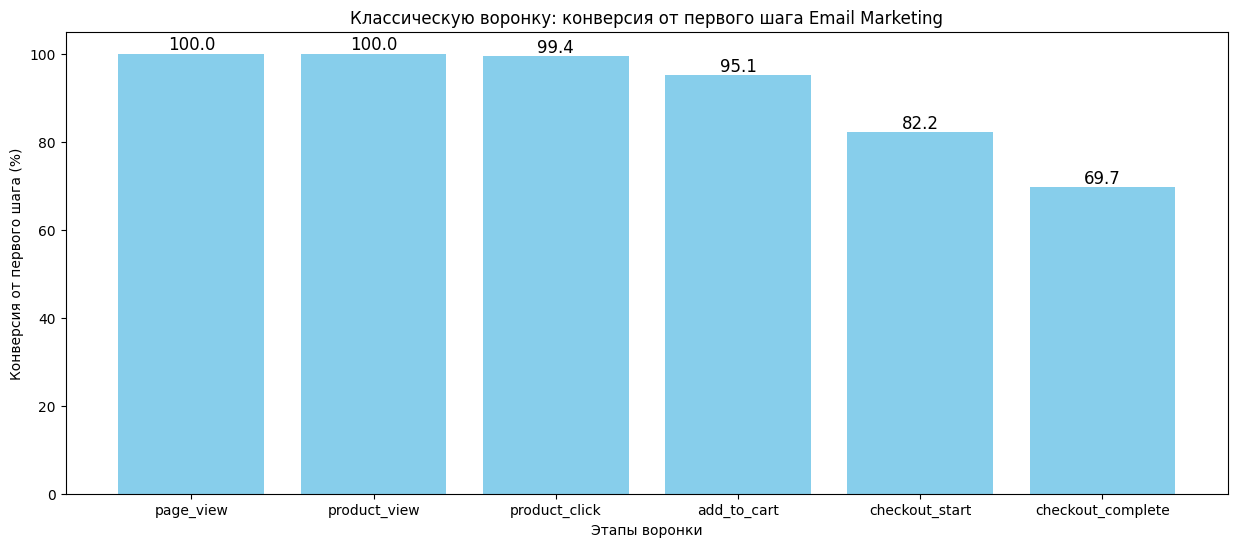

In [47]:
#Подготавливаем данные для рассчёта воронки
conversion = ['page_view', 'product_view','product_click','add_to_cart','checkout_start','checkout_complete']
conversion_df = pd.merge(pa_marketplace_events, pa_marketplace_users[['user_id', 'acq_channel']], on='user_id', how='left')
conversion_df = conversion_df[conversion_df['acq_channel']=='Email Marketing'] 
funnel_counts =  conversion_df.groupby('event_type')['user_id'].nunique().reindex(conversion)

# Собираем таблицу воронки
funnel_df = pd.DataFrame({
   'step':conversion,
   'users':funnel_counts.values
})
# Добавляем конверсии и округляем до 1 знака после запятой
funnel_df['conversion_from_first_%'] = (funnel_df['users'] / funnel_df['users'].iloc[0] * 100).round(1)
funnel_df['conversion_from_previous_%'] = (funnel_df['users'] / funnel_df['users'].shift(1) * 100).round(1)

# Строим классическую воронку
plt.figure(figsize=(15, 6))
plt.bar(funnel_df['step'], funnel_df['conversion_from_first_%'], color='skyblue')
for i, v in enumerate(funnel_df['conversion_from_first_%']):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize=12)
plt.title('Классическую воронку: конверсия от первого шага Email Marketing')
plt.ylabel('Конверсия от первого шага (%)')
plt.xlabel('Этапы воронки')
plt.show()

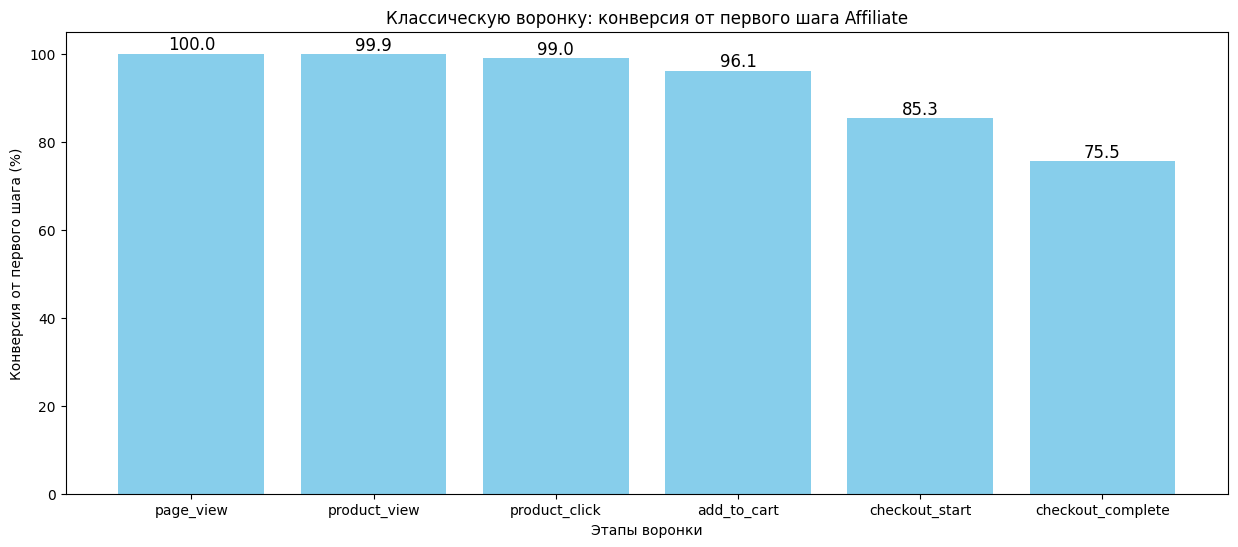

In [48]:
#Подготавливаем данные для рассчёта воронки
conversion = ['page_view', 'product_view','product_click','add_to_cart','checkout_start','checkout_complete']
conversion_df = pd.merge(pa_marketplace_events, pa_marketplace_users[['user_id', 'acq_channel']], on='user_id', how='left')
conversion_df = conversion_df[conversion_df['acq_channel']=='Affiliate'] 
funnel_counts =  conversion_df.groupby('event_type')['user_id'].nunique().reindex(conversion)

# Собираем таблицу воронки
funnel_df = pd.DataFrame({
   'step':conversion,
   'users':funnel_counts.values
})
# Добавляем конверсии и округляем до 1 знака после запятой
funnel_df['conversion_from_first_%'] = (funnel_df['users'] / funnel_df['users'].iloc[0] * 100).round(1)
funnel_df['conversion_from_previous_%'] = (funnel_df['users'] / funnel_df['users'].shift(1) * 100).round(1)

# Строим классическую воронку
plt.figure(figsize=(15, 6))
plt.bar(funnel_df['step'], funnel_df['conversion_from_first_%'], color='skyblue')
for i, v in enumerate(funnel_df['conversion_from_first_%']):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize=12)
plt.title('Классическую воронку: конверсия от первого шага Affiliate')
plt.ylabel('Конверсия от первого шага (%)')
plt.xlabel('Этапы воронки')
plt.show()

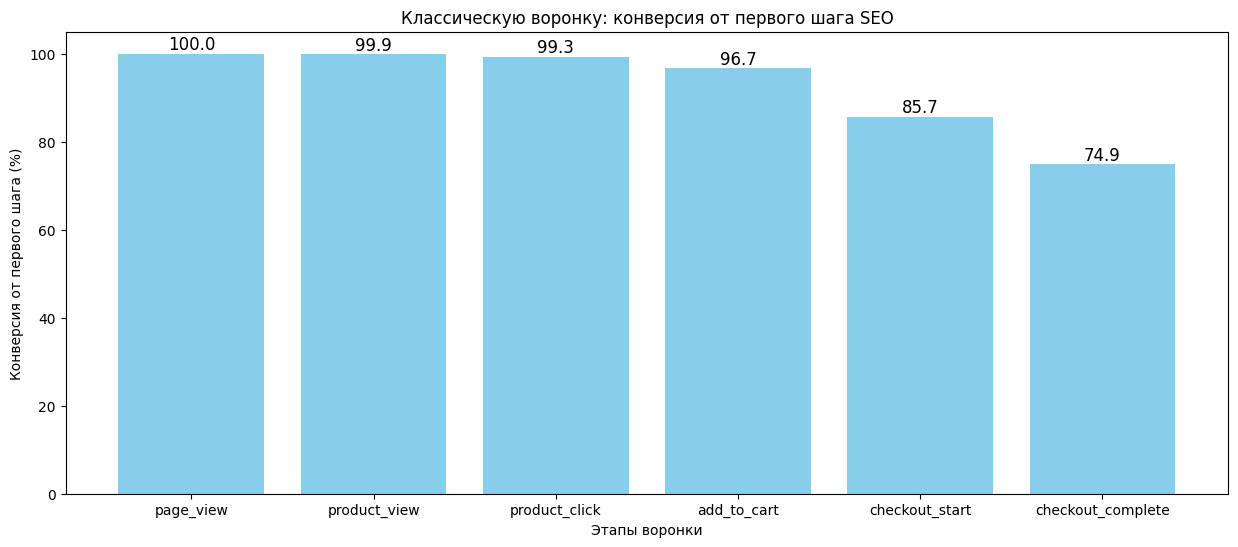

In [49]:
#Подготавливаем данные для рассчёта воронки
conversion = ['page_view', 'product_view','product_click','add_to_cart','checkout_start','checkout_complete']
conversion_df = pd.merge(pa_marketplace_events, pa_marketplace_users[['user_id', 'acq_channel']], on='user_id', how='left')
conversion_df = conversion_df[conversion_df['acq_channel']=='SEO'] 
funnel_counts =  conversion_df.groupby('event_type')['user_id'].nunique().reindex(conversion)

# Собираем таблицу воронки
funnel_df = pd.DataFrame({
   'step':conversion,
   'users':funnel_counts.values
})
# Добавляем конверсии и округляем до 1 знака после запятой
funnel_df['conversion_from_first_%'] = (funnel_df['users'] / funnel_df['users'].iloc[0] * 100).round(1)
funnel_df['conversion_from_previous_%'] = (funnel_df['users'] / funnel_df['users'].shift(1) * 100).round(1)

# Строим классическую воронку
plt.figure(figsize=(15, 6))
plt.bar(funnel_df['step'], funnel_df['conversion_from_first_%'], color='skyblue')
for i, v in enumerate(funnel_df['conversion_from_first_%']):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize=12)
plt.title('Классическую воронку: конверсия от первого шага SEO')
plt.ylabel('Конверсия от первого шага (%)')
plt.xlabel('Этапы воронки')
plt.show()

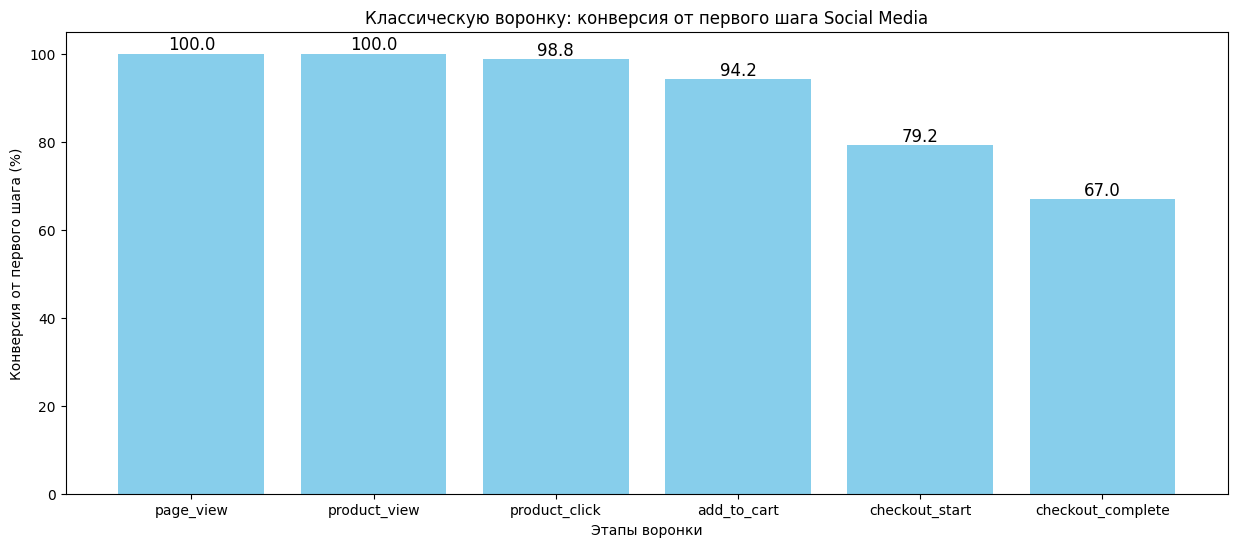

In [50]:
#Подготавливаем данные для рассчёта воронки
conversion = ['page_view', 'product_view','product_click','add_to_cart','checkout_start','checkout_complete']
conversion_df = pd.merge(pa_marketplace_events, pa_marketplace_users[['user_id', 'acq_channel']], on='user_id', how='left')
conversion_df = conversion_df[conversion_df['acq_channel']=='Social Media'] 
funnel_counts =  conversion_df.groupby('event_type')['user_id'].nunique().reindex(conversion)

# Собираем таблицу воронки
funnel_df = pd.DataFrame({
   'step':conversion,
   'users':funnel_counts.values
})
# Добавляем конверсии и округляем до 1 знака после запятой
funnel_df['conversion_from_first_%'] = (funnel_df['users'] / funnel_df['users'].iloc[0] * 100).round(1)
funnel_df['conversion_from_previous_%'] = (funnel_df['users'] / funnel_df['users'].shift(1) * 100).round(1)

# Строим классическую воронку
plt.figure(figsize=(15, 6))
plt.bar(funnel_df['step'], funnel_df['conversion_from_first_%'], color='skyblue')
for i, v in enumerate(funnel_df['conversion_from_first_%']):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize=12)
plt.title('Классическую воронку: конверсия от первого шага Social Media')
plt.ylabel('Конверсия от первого шага (%)')
plt.xlabel('Этапы воронки')
plt.show()

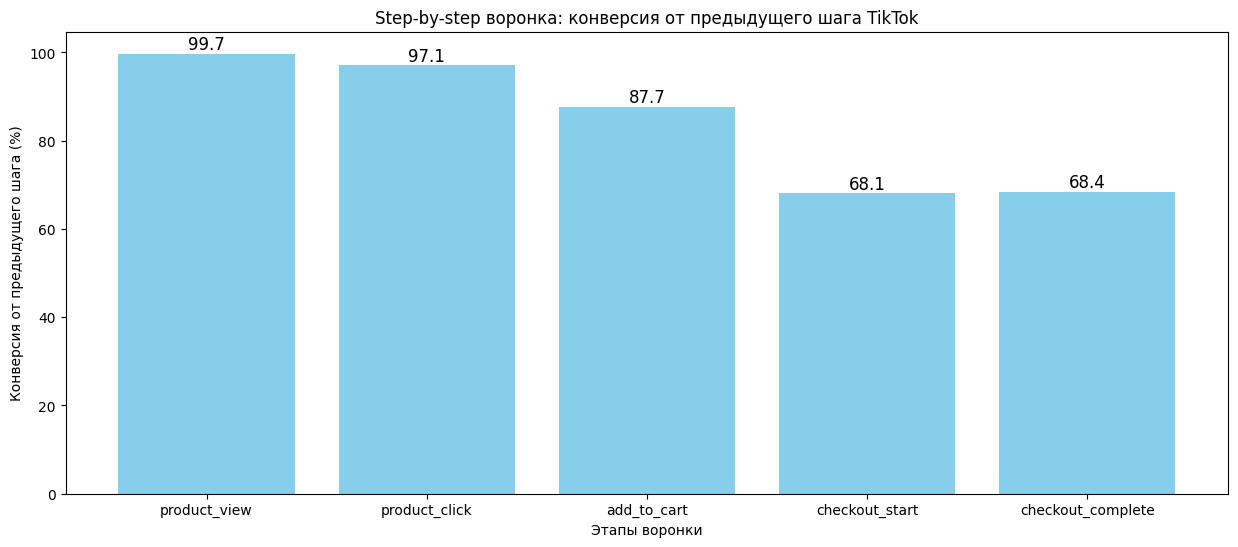

In [51]:
#Подготавливаем данные для рассчёта воронки
conversion = ['page_view', 'product_view','product_click','add_to_cart','checkout_start','checkout_complete']
conversion_df = pd.merge(pa_marketplace_events, pa_marketplace_users[['user_id', 'acq_channel']], on='user_id', how='left')
conversion_df = conversion_df[conversion_df['acq_channel']=='TikTok'] 
funnel_counts =  conversion_df.groupby('event_type')['user_id'].nunique().reindex(conversion)

# Собираем таблицу воронки
funnel_df = pd.DataFrame({
   'step':conversion,
   'users':funnel_counts.values
})
# Добавляем конверсии и округляем до 1 знака после запятой
funnel_df['conversion_from_first_%'] = (funnel_df['users'] / funnel_df['users'].iloc[0] * 100).round(1)
funnel_df['conversion_from_previous_%'] = (funnel_df['users'] / funnel_df['users'].shift(1) * 100).round(1)

# Строим график step-by-step
plt.figure(figsize=(15, 6))
plt.bar(funnel_df['step'][1:], funnel_df['conversion_from_previous_%'][1:], color='skyblue')
for i, v in enumerate(funnel_df['conversion_from_previous_%'][1:]):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize=12)
plt.title('Step-by-step воронка: конверсия от предыдущего шага TikTok')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')
plt.show()

## Выводы по этапу 8

Канал TikTok имеет самое большое число привлеченных клиентов в день с июля. Однако и стоимость привлчения является самой высокой. При этом показатель кликабельности низкий, а ltv приближается к нулю. У пользователей пришедших по каналу TikTok конверсия ухудшается на этапе начала оформления заказа (57,9 % от первого шага и 68,1 % от предыдущего шага). Это самые низкие оказатели конверсии.

Следовательно стоит уменьшить финансирование канала TikTok. И направить данные средства на канал SEO и Email Marketing.

Данные каналы показывают высокую вовлеченность пользователей в продукт и при этом имеют низкую стоимость. Остальные показатели сопостовимы с оставшимися каналами.

Гипотеза 1: При уменьшении финансирования канала TikTok, ROI будет показывать положительную динамику.

Гипотеза 2: При напоминании пользователям, привлеченным из канала TikTok, о заказах в корзине, конверсия на этапах checkout_start и checkout_complete увеличивается.

Гипотеза 3: Если предлагать клиентам, пришедшим из каналов SEO и Email Marketing, персональную скидку в категории украшения и часы, конверсия в группе увеличится.

Гипотеза 4: Предложить клиентам заполнить анкету интересов или текущей заянтости. И если в анкете есть что-то связанное с туризмом, возможно есть новоражденные дети. Предлагать клиентам персональные скидки по данным категориям. Это должно увеличить их конверсию. 

## Подготовка эксперимента и подведение его результатов

# Новые вводные
Команда продукта рассмотрела гипотезы и на основании этого решила влиять на конверсию при помощи финансовых стимуляций. Другой аналитик подготовил дизайн документа, но сам эксперимент был проведён мной.

## Новые данные:
```python
pa_marketplace_events_AB = pd.read_csv('')
pa_marketplace_orders_AB = pd.read_csv('')
pa_marketplace_users_AB = pd.read_csv('')
```
## Результаты сплита лежат в таблице:
```python
pa_marketplace_AB_split_users = pd.read_csv('')
```
* user_id – id клиента
* group – группа, в которую попал клиент


# Дизайн эксперимента: Бонус на первую покупку для пользователей TikTok
## 1. Контекст и цель эксперимента
- **Бизнес-контекст:** Команда продукта запускает эксперимент, направленный на повышение конверсии среди пользователей, привлечённых через канал TikTok. Для стимулирования первой покупки пользователям будет предоставлен бонус на первую покупку.
- **Цель:** Проверить, влияет ли предоставление бонуса на первую покупку на конверсию и выручку среди пользователей TikTok.
- **Гипотеза:** Предоставление бонуса на первую покупку новым пользователям, привлеченным через TikTok, приведет к увеличению конверсии в первую покупку
---
## 2. Формат эксперимента
- **Тип эксперимента:** Сплит-роллинг (rolling split)
- **Канал:** Только пользователи, пришедшие с TikTok
- **Группы:**
    - **Контрольная (A):** пользователи TikTok без бонуса
    - **Тестовая (B):** пользователи TikTok с бонусом на первую покупку
- **Распределение:** Равномерное распределение новых пользователей TikTok между группами по дате регистрации
- **Период проведения:** 3 недели (фиксировано)
---
## 3. Ключевые метрики
### Основная метрика
- **Конверсия в первую покупку** — доля пользователей, зарегистрировавшихся с TikTok и совершивших первую покупку
- *Цель:* увеличить конверсию с помощью бонуса
- *Критерий успеха:* статистически значимый рост конверсии в тестовой группе
### Вспомогательные метрики
- **ARPU** (средняя выручка на пользователя TikTok)
- **ARPPU** (средняя выручка на покупателя TikTok)
- **AOV** (средний чек TikTok)
### Барьерная метрика
- **Общая выручка от пользователей TikTok**
---
## 4. Размеры групп и запуск
- **Целевая аудитория:** только пользователи TikTok
- **Размеры групп:** определяются по фактическому трафику TikTok за период эксперимента
- **Комментарий:** запуск без предварительного расчёта мощности и MDE из-за срочности задачи


In [ ]:
#Загрузка датасетов
pa_marketplace_events_AB = pd.read_csv('',parse_dates=['event_date','event_week','event_month'])
pa_marketplace_orders_AB = pd.read_csv('',parse_dates=['order_date','order_week','order_month'])
pa_marketplace_users_AB = pd.read_csv('',parse_dates=['registration_date','cohort_week','cohort_month'])
#Загрузка сплита A/B теста
pa_marketplace_AB_split_users = pd.read_csv('')

In [53]:
pa_marketplace_events_AB.info()

<class 'pandas.DataFrame'>
RangeIndex: 831231 entries, 0 to 831230
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   event_id      831231 non-null  int64         
 1   user_id       831231 non-null  int64         
 2   event_date    831231 non-null  datetime64[us]
 3   event_type    831231 non-null  str           
 4   os            831231 non-null  str           
 5   device        831231 non-null  str           
 6   product_name  409054 non-null  str           
 7   event_week    831231 non-null  datetime64[us]
 8   event_month   831231 non-null  datetime64[us]
dtypes: datetime64[us](3), int64(2), str(4)
memory usage: 57.1 MB


In [54]:
pa_marketplace_events_AB.head()

,event_id,user_id,event_date,event_type,os,device,product_name,event_week,event_month
0,3132,100,2024-01-01 15:23:56,page_view,iOS,mobile,NaN,2024-01-01,2024-01-01
1,3133,100,2024-01-01 15:24:01,product_view,iOS,mobile,Шорты для тренировок,2024-01-01,2024-01-01
2,3134,100,2024-01-01 15:24:10,product_click,iOS,mobile,Куртка детская,2024-01-01,2024-01-01
3,3135,100,2024-01-01 15:25:10,add_to_cart,iOS,mobile,Балетки классические,2024-01-01,2024-01-01
4,3136,100,2024-01-01 15:25:46,checkout_start,iOS,mobile,NaN,2024-01-01,2024-01-01


In [55]:
print(f'Наличие пропусков в данных \n{pa_marketplace_events_AB.isnull().sum()}')
print(f'\nДубликаты в данных: {pa_marketplace_events_AB.duplicated().sum()}')

Наличие пропусков в данных 
event_id             0
user_id              0
event_date           0
event_type           0
os                   0
device               0
product_name    422177
event_week           0
event_month          0
dtype: int64

Дубликаты в данных: 0


In [56]:
pa_marketplace_orders_AB.info()

<class 'pandas.DataFrame'>
RangeIndex: 33280 entries, 0 to 33279
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       33280 non-null  int64         
 1   user_id        33280 non-null  int64         
 2   order_date     33280 non-null  str           
 3   product_name   33280 non-null  str           
 4   quantity       33280 non-null  int64         
 5   unit_price     33280 non-null  float64       
 6   total_price    33280 non-null  float64       
 7   category_name  33280 non-null  str           
 8   order_week     33280 non-null  datetime64[us]
 9   order_month    33280 non-null  datetime64[us]
dtypes: datetime64[us](2), float64(2), int64(3), str(3)
memory usage: 2.5 MB


In [57]:
pa_marketplace_orders_AB.head()

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
0,1,3,2024-01-19 01:52:52.000,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
1,2,3,2024-01-19 01:52:52.000,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
2,3,3,2024-01-19 01:52:52.000,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
3,4,3,2024-01-25 13:59:38.000,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01
4,5,3,2024-01-25 13:59:38.000,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01


In [58]:
print(f'Наличие пропусков в данных \n{pa_marketplace_orders_AB.isnull().sum()}')
print(f'\nДубликаты в данных: {pa_marketplace_orders_AB.duplicated().sum()}')

Наличие пропусков в данных 
order_id         0
user_id          0
order_date       0
product_name     0
quantity         0
unit_price       0
total_price      0
category_name    0
order_week       0
order_month      0
dtype: int64

Дубликаты в данных: 0


In [59]:
pa_marketplace_users_AB.info()

<class 'pandas.DataFrame'>
RangeIndex: 22196 entries, 0 to 22195
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            22196 non-null  int64         
 1   registration_date  22196 non-null  datetime64[us]
 2   age                22196 non-null  int64         
 3   gender             22196 non-null  str           
 4   region             22196 non-null  str           
 5   acq_channel        22196 non-null  str           
 6   buyer_segment      22196 non-null  str           
 7   cohort_week        22196 non-null  datetime64[us]
 8   cohort_month       22196 non-null  datetime64[us]
dtypes: datetime64[us](3), int64(2), str(4)
memory usage: 1.5 MB


In [60]:
pa_marketplace_users_AB.head()

,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month
0,18,2024-01-01 05:26:00,49,M,Екатеринбург,TikTok,one_time,2024-01-01,2024-01-01
1,22,2024-01-01 17:13:00,50,M,Санкт-Петербург,TikTok,one_time,2024-01-01,2024-01-01
2,26,2024-01-01 21:15:00,60,F,Москва,TikTok,rare,2024-01-01,2024-01-01
3,33,2024-01-01 14:43:00,31,M,Екатеринбург,TikTok,rare,2024-01-01,2024-01-01
4,39,2024-01-01 01:13:00,44,M,Санкт-Петербург,TikTok,rare,2024-01-01,2024-01-01


In [61]:
print(f'Наличие пропусков в данных \n{pa_marketplace_users_AB.isnull().sum()}')
print(f'\nДубликаты в данных: {pa_marketplace_users_AB.duplicated().sum()}')

Наличие пропусков в данных 
user_id              0
registration_date    0
age                  0
gender               0
region               0
acq_channel          0
buyer_segment        0
cohort_week          0
cohort_month         0
dtype: int64

Дубликаты в данных: 0


In [62]:
pa_marketplace_AB_split_users.info()

<class 'pandas.DataFrame'>
RangeIndex: 2968 entries, 0 to 2967
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   user_id  2968 non-null   int64
 1   group    2968 non-null   str  
dtypes: int64(1), str(1)
memory usage: 46.5 KB


In [63]:
print(f'Наличие пропусков в данных \n{pa_marketplace_AB_split_users.isnull().sum()}')
print(f'\nДубликаты в данных: {pa_marketplace_AB_split_users.duplicated().sum()}')

Наличие пропусков в данных 
user_id    0
group      0
dtype: int64

Дубликаты в данных: 0


In [64]:
#Выделяем дату из данных и переводим вы формат datetime
pa_marketplace_users_AB['registration_date'] = pa_marketplace_users_AB['registration_date'].dt.normalize()
pa_marketplace_events_AB['event_date'] = pa_marketplace_events_AB['event_date'].dt.normalize()
pa_marketplace_orders_AB['order_date'] =pa_marketplace_orders_AB['order_date'].dt.normalize()

AttributeError: Can only use .dt accessor with datetimelike values

In [ ]:
#Эксперимент длится 3 недели начиная с 2025 года. Оставляем пользователей, пришедших за время проведения эксперимента
pa_marketplace_users_AB = pa_marketplace_users_AB[pa_marketplace_users_AB['registration_date'] >= '01.01.2025']

pa_marketplace_events_AB = pd.merge(pa_marketplace_events_AB, pa_marketplace_users_AB[['user_id', 'registration_date']], on='user_id', how='left')
pa_marketplace_events_AB = pa_marketplace_events_AB[pa_marketplace_events_AB['registration_date'] >= '01.01.2025']

pa_marketplace_orders_AB = pd.merge(pa_marketplace_orders_AB, pa_marketplace_users_AB[['user_id', 'registration_date']], on='user_id', how='left')
pa_marketplace_orders_AB = pa_marketplace_orders_AB[pa_marketplace_orders_AB['registration_date'] >= '01.01.2025']

In [ ]:
#Глубже анализируем датасет pa_marketplace_AB_split_users
split_users_counts = pa_marketplace_AB_split_users['user_id'].nunique()
print(f'Всего пользователей {split_users_counts}')

split_users = pa_marketplace_AB_split_users.groupby('group')['user_id'].nunique()
print(f'\nРаспределение пользователей по группам: \n{split_users.reset_index()}')

In [ ]:
# Считаем кол-во уникальных групп на user_id
split_data = pa_marketplace_AB_split_users.groupby('user_id')['group'].nunique().reset_index()

# Число клиентов, у которых больше 1 группы
split_data = split_data[split_data['group']>1]

print(f'Клиенты, попавшие в две группы {len(split_data)}')

Составляем гипотезу о равенстве долей пользователей, распределённых по группам теста

H0: pA = pB - доли пользователей в двух группах статистически равны

H1: pA < pB - доля пользователей в контрольной группе меньше

In [ ]:
#Проверка равенства долей с помощью статистического Z-теста на пропорции
alpha = 0.05

stat_ztest, p_value_ztest = proportions_ztest(
    [split_users.loc['control'], split_users.loc['treatment']],
    [split_users_counts, split_users_counts],
    alternative='smaller' # так как H_1: p_a < p_b
)
if p_value_ztest > alpha:
    print(f'pvalue={p_value_ztest} > {alpha}')
    print('Доли пользователей в двух группах статистически равны')
else:
    print(f'pvalue={p_value_ztest} < {alpha}')
    print('Доли пользователей в контрольной группе меньше')

In [ ]:
#Добавляем данные о группе и каналу привлечения к pa_marketplace_events_AB
pa_marketplace_events_AB = pd.merge(pa_marketplace_events_AB, pa_marketplace_AB_split_users, on='user_id', how='left')
pa_marketplace_events_AB = pd.merge(pa_marketplace_events_AB, pa_marketplace_users_AB[['user_id','acq_channel','registration_date']], on='user_id', how='left')

In [ ]:
#Рассчет числа пользователей по этапам воронки по каналу TikTok 
funnel_counts_group =  pa_marketplace_events_AB[pa_marketplace_events_AB['acq_channel']=='TikTok'].groupby(['group','event_type'])['user_id'].nunique().reset_index()

# Сортируем шаги воронки в нужном порядке
funnel_counts_group = funnel_counts_group.set_index(['group','event_type'])
funnel_counts_group= funnel_counts_group.reindex(level='event_type', index = conversion)

In [ ]:
#Рассчёт конверсии по группам
conversion_from_first_control = (funnel_counts_group.xs('control')['user_id'] / funnel_counts_group.xs('control')['user_id'].iloc[0] * 100).round(1)
conversion_from_previous_control = (funnel_counts_group.xs('control')['user_id'] / funnel_counts_group.xs('control')['user_id'].shift(1) * 100).round(1)
conversion_from_first_test = (funnel_counts_group.xs('treatment')['user_id'] / funnel_counts_group.xs('treatment')['user_id'].iloc[0] * 100).round(1)
conversion_from_previous_test = (funnel_counts_group.xs('treatment')['user_id'] / funnel_counts_group.xs('treatment')['user_id'].shift(1) * 100).round(1)

In [ ]:
group_first_control_bar = conversion_from_first_control[1:].plot.bar()
for i, v in enumerate(conversion_from_first_control[1:]):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize=12)
plt.title('Конверсия от первого шага для контрольной группы')
plt.ylabel('Конверсия от первого шага (%)')
plt.xlabel('Этапы воронки')
plt.show()

In [ ]:
group_first_test_bar = conversion_from_first_test[1:].plot.bar()
for i, v in enumerate(conversion_from_first_test[1:]):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize=12)
plt.title('Конверсия от первого шага для тестовой группы')
plt.ylabel('Конверсия от первого шага (%)')
plt.xlabel('Этапы воронки')
plt.show()

In [ ]:
group_previous_control_bar = conversion_from_previous_control[1:].plot.bar()
for i, v in enumerate(conversion_from_previous_control[1:]):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize=12)
plt.title('Конверсия от предыдущего шага для контрольной группы')
plt.ylabel('Конверсия от первого шага (%)')
plt.xlabel('Этапы воронки')
plt.show()

In [ ]:
group_previous_test = conversion_from_previous_test[1:]
group_previous_test_bar = conversion_from_previous_test[1:].plot.bar()
for i, v in enumerate(group_previous_test):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize=12)
plt.title('Конверсия от предыдущего шага для тестовой группы')
plt.ylabel('Конверсия от первого шага (%)')
plt.xlabel('Этапы воронки')
plt.show()

Конверсия от первого шага в тестовой группе на этапах checkout_start и checkout_complete вырасла примерно на 6 %. Конверсия от предыдущего шага на этапе checkout_start вырасла на 6,5%, а на этапе checkout_complete вырасла примерно на 4%

In [ ]:
#Пользователи зарег по каналу TikTok
conversion_registration = pa_marketplace_events_AB[pa_marketplace_events_AB['acq_channel']=='TikTok'].groupby('group')['user_id'].nunique()
#Пользователи зарег по каналу TikTok и совершившие покупку
conversion_purchase = pa_marketplace_events_AB[(pa_marketplace_events_AB['acq_channel']=='TikTok')&(pa_marketplace_events_AB['event_type']=='checkout_complete')].groupby('group')['user_id'].nunique()

#Рассчёт конверсия в первую покупку
conversion = pd.merge(conversion_registration, conversion_purchase, how='left', on='group').rename(columns={'user_id_x':'user_registration',
                                                                                                           'user_id_y':'user_purchase'})
conversion['conversion'] = round(conversion['user_purchase']/conversion['user_registration']*100,2)

Составляем гипотезу о равенстве долей пользователей, распределённых по группам теста

H0: pA = pB - Конверсия пользователей из канала TikTok статистически не изменилась после проведения бонусной программы

H1: pA < pB - Конверсия пользователей из канала TikTok статистически увеличилась после проведения бонусной программы

In [ ]:
#Проверка равенства долей с помощью статистического Z-теста на пропорции
alpha = 0.05

stat_ztest, p_value_ztest = proportions_ztest(
    [conversion.loc['control']['user_purchase'], conversion.loc['treatment']['user_purchase']],
    [conversion.loc['control']['user_registration'], conversion.loc['treatment']['user_registration']],
    alternative='smaller' # так как H_1: p_a < p_b
)
if p_value_ztest > alpha:
    print(f'pvalue={p_value_ztest} > {alpha}')
    print('Конверсия пользователей из канала TikTok статистически не изменилась после проведения бонусной программы')
else:
    print(f'pvalue={p_value_ztest} < {alpha}')
    print('Конверсия пользователей из канала TikTok статистически увеличилась после проведения бонусной программы')

In [ ]:
#Дополняем датафреймы
pa_marketplace_orders_AB['commission'] = pa_marketplace_orders_AB['total_price']*0.05

pa_marketplace_users_AB = pd.merge(pa_marketplace_users_AB, pa_marketplace_AB_split_users, on='user_id', how='left')
pa_marketplace_orders_AB = pd.merge(pa_marketplace_orders_AB, pa_marketplace_AB_split_users, on='user_id', how='left')
pa_marketplace_orders_AB = pd.merge(pa_marketplace_orders_AB, pa_marketplace_users_AB[['user_id', 'acq_channel']], on='user_id', how='left')


users_commission = pa_marketplace_orders_AB.groupby('user_id')['commission'].sum().reset_index()
pa_marketplace_users_AB = pd.merge(pa_marketplace_users_AB, users_commission, how='left', on='user_id')

Составляем гипотезу о равенстве долей пользователей, распределённых по группам теста

H0: pA = pB - Средняя выручка на пользователя не изменилась после проведения бонусной программы

H1: pA < pB - Средняя выручка на пользователя увеличилась после проведения бонусной программы

In [ ]:
#Данные по группам для сравнения arpu
arpu_users_control = pa_marketplace_users_AB[(pa_marketplace_users_AB['acq_channel']=='TikTok')&(pa_marketplace_users_AB['group']=='control')].groupby('user_id')['commission'].sum()
arpu_users_test = pa_marketplace_users_AB[(pa_marketplace_users_AB['acq_channel']=='TikTok')&(pa_marketplace_users_AB['group']=='treatment')].groupby('user_id')['commission'].sum()

#Рассчёт статистической значимости средней суммы выручки на пользователя из канала TikTok
alpha = 0.05

stat_ttest, p_value_ttest = ttest_ind(
    arpu_users_control, 
    arpu_users_test,
    alternative = 'less' # так как H_1: p_a < p_b
)
if p_value_ttest > alpha:
    print(f'pvalue={p_value_ttest} > {alpha}')
    print('Средняя выручка на пользователя не изменилась после проведения бонусной программы')
else:
    print(f'pvalue={p_value_ttest} < {alpha}')
    print('Средняя выручка на пользователя увеличилась после проведения бонусной программы')

Составляем гипотезу о равенстве долей пользователей, распределённых по группам теста

H0: pA = pB - Средняя выручка на плотящего пользователя не изменилась после проведения бонусной программы

H1: pA < pB - Средняя выручка на плотящего пользователя увеличилась после проведения бонусной программы

In [ ]:
#Данные по группам для сравнения arppu
arppu_users_control = pa_marketplace_orders_AB[(pa_marketplace_orders_AB['acq_channel']=='TikTok')&(pa_marketplace_orders_AB['commission']>0)&(pa_marketplace_orders_AB['group']=='control')].groupby('user_id')['commission'].sum()
arppu_revenue_test = pa_marketplace_orders_AB[(pa_marketplace_orders_AB['acq_channel']=='TikTok')&(pa_marketplace_orders_AB['commission']>0)&(pa_marketplace_orders_AB['group']=='treatment')].groupby('user_id')['commission'].sum()

#Рассчёт статистической значимости средней суммы выручки на платящего пользователя из канала TikTok
alpha = 0.05

stat_ttest, p_value_ttest = ttest_ind(
    arppu_users_control, 
    arppu_revenue_test,
    alternative = 'less' # так как H_1: p_a < p_b
)
if p_value_ttest > alpha:
    print(f'pvalue={p_value_ttest} > {alpha}')
    print('Средняя выручка на плотящего пользователя не изменилась после проведения бонусной программы')
else:
    print(f'pvalue={p_value_ttest} < {alpha}')
    print('Средняя выручка на плотящего пользователя увеличилась после проведения бонусной программы')

Составляем гипотезу о равенстве долей пользователей, распределённых по группам теста

H0: pA = pB - Средний чек на плотящего пользователя не изменилась после проведения бонусной программы

H1: pA < pB - Средний чек на плотящего пользователя увеличилась после проведения бонусной программы

In [ ]:
#Данные по группам для сравнения arppu
aov_users_control = pa_marketplace_orders_AB[(pa_marketplace_orders_AB['acq_channel']=='TikTok')&(pa_marketplace_orders_AB['group']=='control')].groupby('user_id')['total_price'].mean()
aov_revenue_test = pa_marketplace_orders_AB[(pa_marketplace_orders_AB['acq_channel']=='TikTok')&(pa_marketplace_orders_AB['group']=='treatment')].groupby('user_id')['total_price'].mean()

#Рассчёт статистической значимости среднего чека из канала TikTok
alpha = 0.05

stat_ttest, p_value_ttest = ttest_ind(
    aov_users_control, 
    aov_revenue_test,
    alternative = 'less' # так как H_1: p_a < p_b
)
if p_value_ttest > alpha:
    print(f'pvalue={p_value_ttest} > {alpha}')
    print('Средний чек на плотящего пользователя не изменилась после проведения бонусной программы')
else:
    print(f'pvalue={p_value_ttest} < {alpha}')
    print('Средний чек на плотящего пользователя увеличилась после проведения бонусной программы')

In [ ]:
total_revenue = pa_marketplace_orders_AB[pa_marketplace_orders_AB['acq_channel']=='TikTok'].groupby('group')['commission'].sum()

In [ ]:
total_revenue_bar = total_revenue.plot.bar()
for i, v in enumerate(round(total_revenue,2)):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize=12)
plt.title('Общая выручка от пользователей TikTok')
plt.ylabel('Общая выручка, руб')
plt.xlabel('Группа эксперимента')
plt.show()

## Выводы

В ходе эксперимента в тестовой группе с помощью бонусной программы удалось увеличить конверсию от первого шага. Конверсия на последних двух этапах выросла на 6 процентов. Конверсия от предыдущего шага на этапе checkout_start вырасла на 6,5%, а на этапе checkout_complete вырасла примерно на 4%. 

Провели z-тест на сравнение конверсии от этапа регистрации к завершению оформления заказа, и выяснили, что конверсия пользователей из канала TikTok статистически не изменилась после проведения бонусной программы. ARPU статистчески выросла в тестовой группе. ARPPU и AOV статистически не изменились. При этом общая выручка от пользователей из канала TikTok выросла в 10 раз.

Из этого можно сделать вывод, что после проведения бонусной программы пользователи стали чаще завершать оформление заказов и оплачивать покупки. Общая выручка выросла в 10 раз. Однако средняя сумма вырочки и чеков статистически не изменилась. 

Бонусную программу можно назвать успешной. Однако изменение конверсии незначительно. Есть еще большой потенциал для роста выручки от пользователей из данного канала. Поэтому необходимо придумывать дополнительный стимул для пользователей TikTok, чтобы выравнить его с другими каналами привлечения. 